# Quantile recursion as a generator

A numerical test of the model-free half of the paper: **an approximate conditional quantile,
closed into a recursion driven by i.i.d. uniforms, is already a generator**, with error
controlled by the *target's* contraction constant alone,

$$\sup_{t}\;|X_t-\hat X_t|\;\le\;\frac{\vartheta}{1-S},\qquad
\vartheta=\sup_{[0,1]\times D}|\hat q-q|,\qquad S=\sum_i\ell_i<1 .$$

Two things this notebook is careful about, because they are the conceptual content.

**Training is open loop; only generation is closed loop.** The network is fitted by ordinary
supervised regression on windows taken from an observed path. The recursion is never run during
training. It is run only at generation time, on fresh uniforms we draw ourselves.

**The target's innovations are never used.** They are a device in the proof, not an object in
the procedure. What identifies $q$ is the joint law of $(X_t, X_{t-1},\dots,X_{t-k})$, which is
observable. During training $u$ is a *query level* drawn independently; during generation it is
the innovation. The two roles coincide only through Rosenblatt's transform, which is why this
works at all.

No echo state network is needed for any of the above. Section 11 wraps the trained map into one
anyway, to check the exact-shift realisation numerically.

## 0. Setup

In [382]:
import numpy as np, torch, torch.nn as nn, time
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 9, "figure.dpi": 110})
np.set_printoptions(precision=4, suppress=True)
torch.set_num_threads(4)

### Configuration

Everything you are likely to change lives here.

In [ ]:
CFG = dict(
    # ---- target -----------------------------------------------------------
    target      = "arch",      # "linear" | "hetero" | "longmem" | "arma" | "arch" | "skew" | "smoothnl"
    k           = 10,             # memory order of the target (assumed known)
    ell         = [0.45, 0.20],  # per-lag moduli, used by the linear target
    alpha       = [0.35, 0.15],  # autoregressive part of the hetero target
    s0          = 0.45,          # conditional scale s(z) = s0 + s1*tanh(kappa*z_1)
    s1          = 0.45,
    kappa       = 1.2,
    M           = 1.0,           # state space is X = [-M, M]
    noise       = "truncnorm",   # "truncnorm" | "uniform"
    lam0        = 0.7,            # skew
    arch_a      = [0.20, 0.10],   # arch
    omega       = 0.2,
    beta        = [0.50, 0.25],   # smoothnl
    h           = 0.55,
    phi         = [0.20],         # arma
    theta       = [0.25],
    decay       = "polynomial",   # longmem: geometric | polynomial | fractional
    S_target    = 0.75,
    n_lag       = 4000,
    r           = 0.8,
    alpha_decay = 0.5,
    d           = 0.3,
    m_fit       = 8,              # fitting arity for arma / longmem
    # ---- data -------------------------------------------------------------
    T_train     = 60_000,        # length of the single observed path
    burn        = 2_000,
    seed_path   = 1,
    # ---- network ----------------------------------------------------------
    width       = 256,           # one hidden layer
    act         = "softclip",    # "tanh" | "softclip" (softclip is affine on an interval)
    seed_net    = 0,
    # ---- training ---------------------------------------------------------
    epochs      = 40,
    batch       = 512,
    lr          = 3e-3,
    lip_mode    = "penalty",     # "none" | "penalty" | "penalty_analytic" | "project"
    L_max       = 0.85,          # target for sum_i Lip_i(qhat); must be < 1
    lam         = 5.0,
    tail_frac   = 0.25,           # fraction of u's to sample from the tails
    edge        = 0.02,          # width of the tails
    # ---- evaluation -------------------------------------------------------
    T_eval      = 40_000,
    seed_eval   = 99,
    strike      = 0.10,
    n_exercise  = 5,
)

## 1. Library

Three cells: targets and simulation, the network and its training, the comparison metrics.
Nothing below this section needs editing.

#### 1a. Targets, assumption checking, simulation

In [384]:
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import norm

# ----------------------------------------------------------------------------
# Innovation transforms g : [0,1] -> [-c, c], continuous and nondecreasing
# ----------------------------------------------------------------------------

def g_uniform(u, c):
    return c * (2.0 * u - 1.0)

def g_truncnorm(u, c, T=2.0):
    lo, hi = norm.cdf(-T), norm.cdf(T)
    return c * norm.ppf(lo + u * (hi - lo)) / T

NOISE = {"uniform": g_uniform, "truncnorm": g_truncnorm}


# ----------------------------------------------------------------------------
# Targets
# ----------------------------------------------------------------------------

class LinearTarget:
    """q(u;z) = sum_i ell_i z_i + g(u).   Per-lag moduli are exactly ell_i.

    This is the sharpness family of the paper's Perron lemma: X-valued on X^k,
    prescribed moduli, and q known in closed form so that theta can be measured.
    """
    def __init__(self, ell, M=1.0, noise="truncnorm"):
        self.ell = np.asarray(ell, dtype=float)
        self.k = len(self.ell)
        self.M = float(M)
        self.S = float(self.ell.sum())
        assert self.S < 1.0, "S must be < 1"
        self.c = self.M * (1.0 - self.S)          # noise amplitude
        self.noise = noise
        self.g = lambda u: NOISE[noise](u, self.c)
        self.name = f"Linear(k={self.k}, S={self.S:.3f})"

    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return z @ self.ell + self.g(u)

    def step(self, gu, z):
        return float(z @ self.ell + gu)

    def moduli(self):
        return self.ell.copy()


class HeteroTarget:
    """q(u;z) = z.alpha + s(z) g(u),  s(z) = s0 + s1 tanh(kappa z_1).

    Non-additive: the conditional *shape* depends on the state.  Per-lag moduli
    ell_1 = alpha_1 + s1 kappa c, ell_i = alpha_i (i >= 2).
    """
    def __init__(self, alpha, s0=0.6, s1=0.35, kappa=2.0, M=1.0, noise="truncnorm"):
        self.alpha = np.asarray(alpha, dtype=float)
        self.k = len(self.alpha)
        self.M = float(M)
        self.s0, self.s1, self.kappa = float(s0), float(s1), float(kappa)
        A = float(self.alpha.sum())
        assert A < 1.0
        # range: |z.alpha| <= M A ; |s| <= s0+s1 ; need M A + (s0+s1) c <= M
        self.c = self.M * (1.0 - A) / (self.s0 + self.s1)
        self.ell = self.alpha.copy()
        self.ell[0] += self.s1 * self.kappa * self.c
        self.S = float(self.ell.sum())
        assert self.S < 1.0, f"S = {self.S:.3f} must be < 1; lower kappa or s1"
        self.noise = noise
        self.g = lambda u: NOISE[noise](u, self.c)
        self.name = f"Hetero(k={self.k}, S={self.S:.3f})"

    def scale(self, z):
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return self.s0 + self.s1 * np.tanh(self.kappa * z[:, 0])

    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return z @ self.alpha + self.scale(z) * self.g(u)

    def step(self, gu, z):
        return float(z @ self.alpha + (self.s0 + self.s1 * np.tanh(self.kappa * z[0])) * gu)

    def moduli(self):
        return self.ell.copy()

class ARMATarget:
    """Bounded ARMA(p,q):  X_t = sum_j phi_j X_{t-j} + eps_t + sum_j theta_j eps_{t-j},
    eps_t = g(u_t) bounded in [-c, c].
 
    Inverted, this is an AR(infinity):  q(u; X_{<t}) = sum_{i>=1} pi_i X_{t-i} + g(u),
    so the target has NO finite memory order and satisfies Assumption 7.1 rather
    than 2.2.  It is the object prop:trunc and cor:ccadapted are for: fitting at
    arity m pays the truncation term 2*M*L_{m+1} with L_{m+1} = sum_{i>m}|pi_i|.
 
    pi is obtained from theta(B) * A(B) = phi(B) with A(B) = 1 - sum_i pi_i B^i:
        a_0 = 1,   a_n = -phi_n*1{n<=p} - sum_{j=1..min(n,q)} theta_j a_{n-j},
        pi_n = -a_n.
    """
    def __init__(self, phi=(), theta=(), M=1.0, noise="truncnorm", n_pi=400):
        self.phi = np.asarray(phi, dtype=float)
        self.theta = np.asarray(theta, dtype=float)
        self.p, self.q_ord = len(self.phi), len(self.theta)
        self.M = float(M)
        if self.q_ord and np.abs(self.theta).sum() >= 1.0:
            raise ValueError("MA part must be invertible: sum|theta| < 1")
        # AR(infinity) coefficients
        a = np.zeros(n_pi + 1); a[0] = 1.0
        for n in range(1, n_pi + 1):
            s = -(self.phi[n - 1] if n <= self.p else 0.0)
            for j in range(1, min(n, self.q_ord) + 1):
                s -= self.theta[j - 1] * a[n - j]
            a[n] = s
        self.pi = -a[1:]                            # pi_1, pi_2, ...
        self.S = float(np.abs(self.pi).sum())
        assert self.S < 1.0, (f"S = {self.S:.3f} must be < 1; "
                              "for pure MA(1) this needs |theta| < 1/2")
        self.c = self.M * (1.0 - self.S)
        self.noise = noise
        self.g = lambda u: NOISE[noise](u, self.c)
        self.k = None                                # no finite memory order
        self.name = f"ARMA(p={self.p},q={self.q_ord}, S={self.S:.3f})"
 
    # ---- truncation bookkeeping, the quantity prop:trunc prices ------------
    def S_trunc(self, m):
        return float(np.abs(self.pi[:m]).sum())
 
    def L_tail(self, m):
        """L_{m+1} = sum_{i>m} |pi_i|; the truncation error is 2*M*L_{m+1}."""
        return float(np.abs(self.pi[m:]).sum())
 
    def moduli(self, m=None):
        return np.abs(self.pi[:m]) if m else np.abs(self.pi)
 
    # ---- the quantile, truncated at the arity of z -------------------------
    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return z @ self.pi[:z.shape[1]] + self.g(u)
 
    def truncate(self, m):
        """A k-Markov view of the AR(infinity), i.e. q_m of prop:trunc with
        anchor zero.  Usable anywhere a normal target is: simulate_target,
        verify_assumptions, theta_profile.  Fitting the network at arity m and
        comparing against the EXACT ARMA path is the cor:ccadapted experiment;
        the irreducible term is 2*M*L_tail(m)."""
        return _ARMATruncation(self, m)
 
    # ---- exact simulation in ARMA form (p+q state, no truncation) ----------
    def simulate(self, n, burn=2000, seed=0, u_stream=None):
        rng = np.random.default_rng(seed)
        total = burn + n
        u = rng.random(total) if u_stream is None else np.asarray(u_stream, float)[:total]
        e = self.g(u)
        x = np.zeros(total)
        for t in range(total):
            v = e[t]
            for j in range(1, self.p + 1):
                if t - j >= 0: v += self.phi[j - 1] * x[t - j]
            for j in range(1, self.q_ord + 1):
                if t - j >= 0: v += self.theta[j - 1] * e[t - j]
            x[t] = v
        return x[burn:]

class _ARMATruncation:
    """q_m(u; z_1..z_m) = sum_{i<=m} pi_i z_i + g(u).  Anchor is zero."""
    def __init__(self, parent, m):
        self.parent, self.k, self.M = parent, m, parent.M
        self.pi_m = parent.pi[:m].copy()
        self.S = float(np.abs(self.pi_m).sum())
        self.c, self.g, self.noise = parent.c, parent.g, parent.noise
        self.L_tail = parent.L_tail(m)
        self.name = f"{parent.name} truncated to m={m} (S_m={self.S:.3f}, 2M*L={2*self.M*self.L_tail:.4f})"
 
    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return z @ self.pi_m + self.g(u)
 
    def step(self, gu, z):
        return float(z @ self.pi_m + gu)
 
    def moduli(self):
        return np.abs(self.pi_m)


class ARCHTarget:
    """Bounded ARCH(k):  X_t = sqrt(omega + sum_i a_i X_{t-i}^2) * g(u_t).
 
    Zero conditional mean, state-dependent conditional scale.  Genuinely
    k-Markov in the observable, unlike GARCH, whose latent volatility state has
    no finite invertible representation in X.
 
        dq/dz_i = g(u) * a_i z_i / sqrt(omega + sum_j a_j z_j^2),
        ell_i   = c * a_i * M / sqrt(omega + a_i M^2)      (other coords zero
                  maximise the ratio, since they only inflate the denominator)
        range   |q| <= c * sqrt(omega + M^2 * sum a_i) <= M  fixes c.
    """
    def __init__(self, a, omega=0.2, M=1.0, noise="truncnorm"):
        self.a = np.asarray(a, dtype=float)
        assert (self.a >= 0).all(), "ARCH coefficients must be nonnegative"
        self.k = len(self.a)
        self.M, self.omega = float(M), float(omega)
        A = float(self.a.sum())
        self.c = self.M / np.sqrt(self.omega + self.M ** 2 * A)
        self.ell = self.c * self.a * self.M / np.sqrt(self.omega + self.a * self.M ** 2)
        self.S = float(self.ell.sum())
        assert self.S < 1.0, (f"S = {self.S:.3f} must be < 1; "
                              "raise omega or lower the a_i")
        self.noise = noise
        self.g = lambda u: NOISE[noise](u, self.c)
        self.name = f"ARCH(k={self.k}, S={self.S:.3f})"
 
    def sigma_of(self, z):
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return np.sqrt(self.omega + z ** 2 @ self.a)
 
    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return self.sigma_of(z) * self.g(u)
 
    def step(self, gu, z):
        return float(np.sqrt(self.omega + float(z ** 2 @ self.a)) * gu)
 
    def moduli(self):
        return self.ell.copy()

class SmoothNonlinearAR:
    """X_t = H*tanh( (sum_i beta_i X_{t-i}) / H ) + g(u_t),  H = h*M.
 
    Nonlinear conditional mean, homoskedastic.  Nothing else in the suite tests
    a nonlinear mean: LinearTarget and ARMA are affine in z, ARCH and Hetero put
    the nonlinearity in the scale.
 
        dq/dz_i = beta_i * sech^2(.)  ->  ell_i = |beta_i|  (attained at z = 0)
        range   |q| <= H + c <= M     ->  c = (1-h) M
    Small h saturates the tanh and makes the nonlinearity strong.
    """
    def __init__(self, beta, h=0.6, M=1.0, noise="truncnorm"):
        self.beta = np.asarray(beta, dtype=float)
        self.k = len(self.beta)
        self.M, self.h = float(M), float(h)
        self.H = self.h * self.M
        self.c = (1.0 - self.h) * self.M
        self.ell = np.abs(self.beta)
        self.S = float(self.ell.sum())
        assert self.S < 1.0, f"S = {self.S:.3f} must be < 1"
        assert 0.0 < h < 1.0
        self.noise = noise
        self.g = lambda u: NOISE[noise](u, self.c)
        self.name = f"SmoothNL(k={self.k}, S={self.S:.3f}, h={h})"
 
    def mean_of(self, z):
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return self.H * np.tanh((z @ self.beta) / self.H)
 
    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        return self.mean_of(z) + self.g(u)
 
    def step(self, gu, z):
        return float(self.H * np.tanh(float(z @ self.beta) / self.H) + gu)
 
    def moduli(self):
        return self.ell.copy()

class SkewTarget:
    """State-dependent conditional SKEWNESS, with the conditional mean fixed.
 
        v = 2u - 1 in [-1,1],   psi(v; lam) = v + lam|v| - lam/2   (mean zero)
        q(u; z)   = z.alpha + c * psi(2u-1; lam(z)),  lam(z) = lam0 tanh(kappa z_1)
 
    psi is nondecreasing in v for |lam| < 1, and centred so that E[q | z] = z.alpha
    exactly.  The conditional variance moves only mildly; the third moment flips
    sign with z_1.  No second-order diagnostic can see this: not the ACF, not the
    ACF of squares, not the conditional standard deviation.  A matched Gaussian
    AR and a matched GARCH are both blind to it.
 
        d psi / d lam = |v| - 1/2  in [-1/2, 1/2]
        ell_1 = alpha_1 + c*lam0*kappa/2,   ell_i = alpha_i
        range |q| <= M*sum(alpha) + c(1 + lam0/2) <= M  fixes c.
 
    NOTE: this target consumes the RAW uniform, because the innovation transform
    depends on the state.  self.g is therefore the identity, which keeps
    simulate_target usable unchanged.
    """
    def __init__(self, alpha, lam0=0.7, kappa=1.5, M=1.0):
        self.alpha = np.asarray(alpha, dtype=float)
        self.k = len(self.alpha)
        self.M = float(M)
        self.lam0, self.kappa = float(lam0), float(kappa)
        assert 0.0 <= self.lam0 < 1.0, "need |lam| < 1 for monotonicity in u"
        A = float(self.alpha.sum())
        assert A < 1.0
        self.c = self.M * (1.0 - A) / (1.0 + self.lam0 / 2.0)
        self.ell = self.alpha.copy()
        self.ell[0] += self.c * self.lam0 * self.kappa / 2.0
        self.S = float(self.ell.sum())
        assert self.S < 1.0, f"S = {self.S:.3f} must be < 1; lower lam0 or kappa"
        self.noise = "raw-uniform"
        self.g = lambda u: np.asarray(u, dtype=float)      # identity on purpose
        self.name = f"Skew(k={self.k}, S={self.S:.3f}, lam0={lam0})"
 
    def lam_of(self, z):
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return self.lam0 * np.tanh(self.kappa * z[:, 0])
 
    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        z = np.atleast_2d(np.asarray(z, dtype=float))
        v = 2.0 * u - 1.0
        lam = self.lam_of(z)
        return z @ self.alpha + self.c * (v + lam * np.abs(v) - lam / 2.0)
 
    def step(self, u, z):
        v = 2.0 * float(u) - 1.0
        lam = self.lam0 * np.tanh(self.kappa * float(z[0]))
        return float(z @ self.alpha + self.c * (v + lam * abs(v) - lam / 2.0))
 
    def moduli(self):
        return self.ell.copy()

class LongMemoryTarget:
    """X_t = sum_{i>=1} phi_i X_{t-i} + g(u_t),  phi_i >= 0 summable, S = sum phi_i < 1.
 
    The coefficient sequence is specified directly rather than induced by a
    rational filter, which is the only way to get a POLYNOMIAL modulus tail.
 
      decay="geometric"   phi_i ∝ r^(i-1)            L_(m+1) ~ r^m       (easy)
      decay="polynomial"  phi_i ∝ i^-(1+alpha)       L_(m+1) ~ m^-alpha  (hard)
      decay="fractional"  phi_i ∝ -C(d,i)(-1)^i      the ARFIMA shape, ~ i^-(1+d)
 
    All three are normalised to a prescribed S.  Truncated at n_lag, so the
    target is n_lag-Markov by construction, but n_lag is in the thousands while
    you fit at arity m in the tens: this is the "1000-Markov target fitted at
    k=2" situation made concrete, and L_tail(m) is exactly what it costs.
    """
    def __init__(self, decay="polynomial", S=0.7, n_lag=4000, r=0.8, alpha=0.5,
                 d=0.3, M=1.0, noise="truncnorm"):
        i = np.arange(1, n_lag + 1, dtype=float)
        if decay == "geometric":
            w = r ** (i - 1)
        elif decay == "polynomial":
            w = i ** (-(1.0 + alpha))
        elif decay == "fractional":
            # phi_j = -binom(d, j)(-1)^j, built by the stable recursion
            w = np.empty(n_lag); w[0] = d
            for j in range(2, n_lag + 1):
                w[j - 1] = w[j - 2] * (j - 1 - d) / j
        else:
            raise ValueError(decay)
        self.phi = float(S) * w / w.sum()
        self.n_lag, self.k = n_lag, n_lag
        self.S = float(self.phi.sum())
        self.M = float(M)
        self.c = self.M * (1.0 - self.S)
        self.noise = noise
        self.g = lambda u: NOISE[noise](u, self.c)
        self.decay = decay
        self.name = f"LongMemory({decay}, S={self.S:.3f}, n_lag={n_lag})"
 
    def L_tail(self, m):
        """L_(m+1) = sum_{i>m} phi_i.  Truncation error is 2*M*L_(m+1)."""
        return float(self.phi[m:].sum())
 
    def S_trunc(self, m):
        return float(self.phi[:m].sum())
 
    def m_required(self, eps, M=None):
        """Smallest m with 2*M*L_(m+1)/(1-S) < eps  (cor:mrate)."""
        M = self.M if M is None else M
        tail = np.concatenate([self.phi[::-1].cumsum()[::-1][1:], [0.0]])
        ok = np.nonzero(2 * M * tail / (1 - self.S) < eps)[0]
        return int(ok[0]) + 1 if len(ok) else None
 
    def moduli(self, m=None):
        return self.phi[:m].copy() if m else self.phi.copy()
 
    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float))
        z = np.atleast_2d(np.asarray(z, dtype=float))
        return z @ self.phi[:z.shape[1]] + self.g(u)
 
    def step(self, gu, z):
        return float(z @ self.phi[:len(z)] + gu)
 
    def simulate(self, n, burn=4000, seed=0, u_stream=None):
        """Exact for the n_lag-truncated coefficient vector."""
        rng = np.random.default_rng(seed)
        total = burn + n
        u = rng.random(total) if u_stream is None else np.asarray(u_stream, float)[:total]
        e = self.g(u)
        x = np.zeros(total)
        L = self.n_lag
        for t in range(total):
            lo = max(0, t - L)
            hist = x[lo:t][::-1]                      # X_{t-1}, X_{t-2}, ...
            x[t] = hist @ self.phi[:len(hist)] + e[t]
        return x[burn:]
 
    def truncate(self, m):
        return _LMTrunc(self, m)
 
 
class _LMTrunc:
    def __init__(self, parent, m):
        self.parent, self.k, self.M = parent, m, parent.M
        self.phi_m = parent.phi[:m].copy()
        self.S = float(self.phi_m.sum())
        self.c, self.g, self.noise = parent.c, parent.g, parent.noise
        self.L_tail = parent.L_tail(m)
        self.name = (f"{parent.name} truncated to m={m} "
                     f"(S_m={self.S:.3f}, 2M*L={2*self.M*self.L_tail:.4f})")
    def q(self, u, z):
        u = np.atleast_1d(np.asarray(u, dtype=float)); z = np.atleast_2d(np.asarray(z, dtype=float))
        return z @ self.phi_m + self.g(u)
    def step(self, gu, z):   return float(z @ self.phi_m + gu)
    def moduli(self):        return self.phi_m.copy()


# ----------------------------------------------------------------------------
# Numerical verification that a target meets the standing assumptions
# ----------------------------------------------------------------------------

def verify_assumptions(target, n_pairs=4000, n_u=201, delta=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    k, M = target.k, target.M
    ugrid = np.linspace(0.0, 1.0, n_u)
    ell_hat = np.zeros(k)
    for i in range(k):
        z = rng.uniform(-M, M, size=(n_pairs, k))
        zp = z.copy()
        step = rng.choice([-1.0, 1.0], size=n_pairs) * delta
        zp[:, i] = np.clip(z[:, i] + step, -M, M)
        d = np.abs(zp[:, i] - z[:, i])
        keep = d > 1e-12
        z, zp, d = z[keep], zp[keep], d[keep]
        worst = 0.0
        for u in ugrid:                     # sup over u of |q(u;z)-q(u;z')| / |dz_i|
            uu = np.full(len(z), u)
            worst = max(worst, float(np.max(np.abs(target.q(uu, zp) - target.q(uu, z)) / d)))
        ell_hat[i] = worst
    # range check
    z = rng.uniform(-M, M, size=(20000, k))
    u = rng.random(20000)
    vals = target.q(u, z)
    return {
        "ell_analytic": target.moduli(),
        "ell_numeric": ell_hat,
        "S_analytic": target.S,
        "S_numeric": float(ell_hat.sum()),
        "range_min": float(vals.min()),
        "range_max": float(vals.max()),
        "X": (-M, M),
        "in_range": bool(vals.min() >= -M - 1e-9 and vals.max() <= M + 1e-9),
    }


# ----------------------------------------------------------------------------
# Simulation of the target
# ----------------------------------------------------------------------------

# HELPER
def simulate_path(tgt, n, burn, seed, u_stream=None):
    """Exact simulation.  ARMA and LongMemory carry their own simulate();
    every k-Markov target goes through simulate_target."""
    sim = getattr(tgt, "simulate", None)
    if callable(sim):                                  # non-Markov: exact recursion
        return sim(n, burn=burn, seed=seed, u_stream=u_stream)
    return simulate_target(tgt, n, burn=burn, seed=seed, u_stream=u_stream)

def simulate_target(target, n, burn=2000, seed=0, u_stream=None, z0=None):
    """Free-running simulation.  Returns the path of length n after burn-in."""
    rng = np.random.default_rng(seed)
    k = target.k
    total = burn + n
    u = rng.random(total) if u_stream is None else np.asarray(u_stream, float)[:total]
    z = np.zeros(k) if z0 is None else np.asarray(z0, float).copy()
    gu = target.g(u)
    out = np.empty(total)
    for t in range(total):
        out[t] = target.step(gu[t], z)
        z[1:] = z[:-1]; z[0] = out[t]
    return out[burn:]


def make_windows(path, k):
    """Supervised pairs (z_t, x_t) with z_t = (X_{t-1},...,X_{t-k})."""
    T = len(path)
    idx = np.arange(k, T)
    Z = np.stack([path[idx - j] for j in range(1, k + 1)], axis=1)
    X = path[idx]
    return Z, X

#### 1b. Activations, the quantile network, training, hypothesis diagnostics, the closed recursion

In [385]:
# ---------------------------------------------------------------------------
# Activations
# ----------------------------------------------------------------------------

class SoftClip(nn.Module):
    """Identity on [-1,1], C^1, bounded by 1+beta.  Affine on an interval,
    which is what the paper's exact-shift block needs and tanh does not have."""
    def __init__(self, beta=0.5):
        super().__init__()
        self.beta = beta

    def forward(self, y):
        b = self.beta
        a = y.abs()
        sat = 1.0 + b * (1.0 - torch.exp(-(a - 1.0).clamp(min=0.0) / b))
        return torch.where(a <= 1.0, y, torch.sign(y) * sat)

    @staticmethod
    def numpy(y, beta=0.5):
        a = np.abs(y)
        sat = 1.0 + beta * (1.0 - np.exp(-np.maximum(a - 1.0, 0.0) / beta))
        return np.where(a <= 1.0, y, np.sign(y) * sat)


ACTS = {"tanh": (nn.Tanh(), 1.0), "softclip": (SoftClip(), 1.0)}  # (module, sup|sigma'|)


# ----------------------------------------------------------------------------
# The quantile network  qhat(u,z) = a^T sigma(G z + c u + zeta) + b
# ----------------------------------------------------------------------------

class QuantileNet(nn.Module):
    def __init__(self, k, width=256, act="tanh", seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.k, self.width, self.act_name = k, width, act
        self.sigma, self.dsup = ACTS[act]
        self.G = nn.Parameter(torch.randn(width, k) / np.sqrt(k))
        self.c = nn.Parameter(torch.randn(width))
        self.zeta = nn.Parameter(0.1 * torch.randn(width))
        self.a = nn.Parameter(torch.randn(width) / np.sqrt(width))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, u, z):
        h = self.sigma(z @ self.G.T + self.c[None, :] * u[:, None] + self.zeta[None, :])
        return h @ self.a + self.b

    def lipschitz_bound(self):
        """Analytic upper bound on sum_i Lip_i(qhat):  sup|sigma'| * sum_j |a_j| ||G_j||_1."""
        return self.dsup * (self.a.abs() * self.G.abs().sum(dim=1)).sum()

    def rescale_G(self, factor):
        with torch.no_grad():
            self.G.mul_(factor)

    @torch.no_grad()
    def q_np(self, u, z):
        u = torch.as_tensor(np.atleast_1d(u), dtype=torch.float32)
        z = torch.as_tensor(np.atleast_2d(z), dtype=torch.float32)
        return self.forward(u, z).numpy()


# ----------------------------------------------------------------------------
# Randomised pinball training
# ----------------------------------------------------------------------------

def grad_lip(net, z, u):
    """Differentiable estimate of sum_i sup_z |d qhat / d z_i| over the batch.
    This is the quantity the uniqueness condition is about; the analytic
    bound sum_j |a_j| ||G_j||_1 is the same thing bounded worst-case."""
    z = z.detach().requires_grad_(True)
    out = net(u, z).sum()
    gr, = torch.autograd.grad(out, z, create_graph=True)
    return gr.abs().max(dim=0).values.sum()

def sample_u(n, gen, tail_frac=0.0, edge=0.02, u_min=1e-4):
    u = torch.rand(n, generator=gen)
    if tail_frac <= 0.0:
        return u
    m  = torch.rand(n, generator=gen) < tail_frac
    s  = torch.rand(n, generator=gen)
    lo, hi_ = float(np.log(u_min)), float(np.log(edge))
    t  = torch.exp(lo + (hi_ - lo) * s)          # log-uniform on [u_min, edge]
    hi = torch.rand(n, generator=gen) < 0.5
    return torch.where(m, torch.where(hi, 1.0 - t, t), u)


def pinball(pred, x, u):
    e = x - pred
    return torch.maximum(u * e, (u - 1.0) * e).mean()

def train(net, Z, X, epochs=30, batch=512, lr=2e-3, lip_mode="penalty",
          L_max=0.95, lam=10.0, M=1.0, box_frac=1.0, seed=0, log_every=5,
          n_monitor=512, verbose=True, tail_frac=0.0, edge=0.02):
    """Randomised pinball regression with a Lipschitz penalty enforced on the
    whole state space, not only on the windows the data visits.

    lip_mode:
      "penalty"           gradient-based, on data windows + uniform box windows
      "penalty_analytic"  the conservative closed-form bound (usually vacuous)
      "project"           rescale G after each step using the analytic bound
      "none"              no constraint
    """
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    Zt = torch.as_tensor(Z, dtype=torch.float32)
    Xt = torch.as_tensor(X, dtype=torch.float32)
    n = len(Xt)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = []

    for ep in range(epochs):
        perm = torch.randperm(n, generator=gen)
        tot, nb = 0.0, 0
        for s in range(0, n, batch):
            idx = perm[s:s + batch]
            z, x = Zt[idx], Xt[idx]
            # u = torch.rand(len(idx), generator=gen)
            u = sample_u(len(idx), gen, tail_frac, edge) # sample u with tail fraction

            loss = pinball(net(u, z), x, u)

            if lip_mode == "penalty":
                nb_ = int(box_frac * len(idx))
                zp = torch.rand(nb_, net.k, generator=gen) * 2 * M - M
                zc = torch.cat([z, zp])
                uc = torch.cat([u, torch.rand(nb_, generator=gen)])
                loss = loss + lam * torch.relu(grad_lip(net, zc, uc) - L_max) ** 2
            elif lip_mode == "penalty_analytic":
                loss = loss + lam * torch.relu(net.lipschitz_bound() - L_max) ** 2

            opt.zero_grad(); loss.backward(); opt.step()

            if lip_mode == "project":
                with torch.no_grad():
                    B2 = net.lipschitz_bound().item()
                    if B2 > L_max:
                        net.rescale_G(L_max / B2)

            tot += loss.item(); nb += 1

        sched.step()

        # monitor the quantity that is actually constrained, on the state space
        zmon = torch.rand(n_monitor, net.k, generator=gen) * 2 * M - M
        umon = torch.rand(n_monitor, generator=gen)
        L_box = float(grad_lip(net, zmon, umon).detach())
        hist.append({"epoch": ep, "loss": tot / nb, "lip_box": L_box,
                     "lip_analytic": net.lipschitz_bound().item()})
        if verbose and (ep % log_every == 0 or ep == epochs - 1):
            print(f"  epoch {ep:3d}   pinball {tot/nb:.5f}   "
                  f"sum_i Lip_i on the state space {L_box:.3f}")
    return hist


# ----------------------------------------------------------------------------
# Diagnostics on the hypotheses of the generator proposition
# ----------------------------------------------------------------------------

def theta_hat(net, target, region="state_space", Z_data=None, n_z=4000, n_u=64, seed=0):
    """sup |qhat - q| over a region of windows, times a grid of quantile levels."""
    rng = np.random.default_rng(seed)
    k, M = target.k, target.M
    if region == "state_space":
        z = rng.uniform(-M, M, size=(n_z, k))
    elif region == "data":
        z = Z_data[rng.integers(0, len(Z_data), size=n_z)]
    else:
        raise ValueError(region)
    u = np.linspace(1e-3, 1 - 1e-3, n_u)
    worst = 0.0
    for uu in u:
        uv = np.full(len(z), uu)
        worst = max(worst, float(np.max(np.abs(net.q_np(uv, z) - target.q(uv, z)))))
    return worst


def theta_profile(net, target, region="data", Z_data=None, n_z=3000,
                   u_grid=None, seed=0):
    """Worst |qhat - q| at each quantile level.  The uniform hypothesis of the
    generator proposition is the max of this over all u in [0,1]; the tails are
    where it is hard, which is the uniformity-in-u gap."""
    rng = np.random.default_rng(seed)
    k, M = target.k, target.M
    if region == "state_space":
        z = rng.uniform(-M, M, size=(n_z, k))
    else:
        z = Z_data[rng.integers(0, len(Z_data), size=n_z)]
    if u_grid is None:
        u_grid = np.concatenate([np.linspace(1e-3, 0.05, 12),
                                 np.linspace(0.05, 0.95, 37),
                                 np.linspace(0.95, 1 - 1e-3, 12)])
    err = np.array([float(np.max(np.abs(net.q_np(np.full(len(z), uu), z)
                                        - target.q(np.full(len(z), uu), z))))
                    for uu in u_grid])
    return u_grid, err


def theta_trimmed(u_grid, err, eps):
    """sup |qhat - q| over quantile levels in [eps, 1-eps]."""
    m = (u_grid >= eps) & (u_grid <= 1 - eps)
    return float(err[m].max()) if m.any() else np.nan


def lipschitz_empirical(net, z, n_u=32, seed=0):
    """sum_i sup_z |d qhat / d z_i| over the supplied windows."""
    z = torch.tensor(np.asarray(z), dtype=torch.float32, requires_grad=True)
    per = torch.zeros(net.k)
    for uu in np.linspace(1e-3, 1 - 1e-3, n_u):
        u = torch.full((len(z),), float(uu))
        gr, = torch.autograd.grad(net(u, z).sum(), z)
        per = torch.maximum(per, gr.abs().max(0).values)
    return per.detach().numpy()


# ----------------------------------------------------------------------------
# The closed recursion
# ----------------------------------------------------------------------------

class ClosedQuantileRecursion:
    """X_t = qhat(u_t; X_{t-1},...,X_{t-k}) with fresh i.i.d. uniforms.

    No window, no seed and no burn-in are required by the theory; burn-in below
    is purely numerical, to let the unique solution be reached.
    """
    def __init__(self, net):
        self.net = net
        self.k = net.k
        self.G = net.G.detach().numpy().astype(np.float64)
        self.c = net.c.detach().numpy().astype(np.float64)
        self.zeta = net.zeta.detach().numpy().astype(np.float64)
        self.a = net.a.detach().numpy().astype(np.float64)
        self.b = float(net.b.detach().numpy()[0])
        self.beta = getattr(net.sigma, "beta", None)
        self.act = net.act_name

    def _sigma(self, y):
        if self.act == "tanh":
            return np.tanh(y)
        return SoftClip.numpy(y, self.beta)

    def q(self, u, z):
        """One step of the learned quantile map, in numpy."""
        return float(self._sigma(self.G @ z + self.c * u + self.zeta) @ self.a + self.b)

    def generate(self, n, burn=2000, seed=0, u_stream=None, z0=None):
        rng = np.random.default_rng(seed)
        total = burn + n
        u = rng.random(total) if u_stream is None else np.asarray(u_stream, float)[:total]
        z = np.zeros(self.k) if z0 is None else np.asarray(z0, float).copy()
        out = np.empty(total)
        for t in range(total):
            out[t] = self.q(u[t], z)
            z[1:] = z[:-1]; z[0] = out[t]
        return out[burn:]

#### 1c. Comparison metrics

In [386]:
import numpy as np
from scipy.stats import norm


# ---------------------------------------------------------------- path-law ---

def acf(x, nlags=25):
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    denom = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[:-l], x[l:]) / denom for l in range(1, nlags + 1)])


def w1_marginal(x, y):
    """1-Wasserstein between empirical marginals (1D: sorted-quantile L1 gap)."""
    m = min(len(x), len(y))
    qs = (np.arange(m) + 0.5) / m
    qx = np.quantile(np.asarray(x, float), qs)
    qy = np.quantile(np.asarray(y, float), qs)
    return float(np.mean(np.abs(qx - qy)))


def blocks(path, L, stride=1):
    idx = np.arange(0, len(path) - L + 1, stride)
    return np.stack([path[i:i + L] for i in idx])


def _rbf(A, B, gamma):
    d = ((A[:, None, :] - B[None, :, :]) ** 2).sum(-1)
    return np.exp(-gamma * d)


def mmd2_unbiased(A, B, gamma=None, max_n=1200, seed=0):
    """Unbiased MMD^2 with an RBF kernel; median-heuristic bandwidth."""
    rng = np.random.default_rng(seed)
    if len(A) > max_n:
        A = A[rng.choice(len(A), max_n, replace=False)]
    if len(B) > max_n:
        B = B[rng.choice(len(B), max_n, replace=False)]
    if gamma is None:
        Z = np.vstack([A, B])
        sub = Z[rng.choice(len(Z), min(500, len(Z)), replace=False)]
        d2 = ((sub[:, None, :] - sub[None, :, :]) ** 2).sum(-1)
        med = np.median(d2[d2 > 0])
        gamma = 1.0 / med
    m, n = len(A), len(B)
    Kaa, Kbb, Kab = _rbf(A, A, gamma), _rbf(B, B, gamma), _rbf(A, B, gamma)
    np.fill_diagonal(Kaa, 0.0); np.fill_diagonal(Kbb, 0.0)
    return float(Kaa.sum() / (m * (m - 1)) + Kbb.sum() / (n * (n - 1)) - 2 * Kab.mean()), gamma


def mmd_permutation_test(A, B, n_perm=200, gamma=None, max_n=1200, seed=0):
    rng = np.random.default_rng(seed)
    obs, gamma = mmd2_unbiased(A, B, gamma=gamma, max_n=max_n, seed=seed)
    if len(A) > max_n: A = A[rng.choice(len(A), max_n, replace=False)]
    if len(B) > max_n: B = B[rng.choice(len(B), max_n, replace=False)]
    Z = np.vstack([A, B]); m = len(A)
    null = np.empty(n_perm)
    for i in range(n_perm):
        p = rng.permutation(len(Z))
        null[i], _ = mmd2_unbiased(Z[p[:m]], Z[p[m:]], gamma=gamma, max_n=max_n, seed=i)
    return {"mmd2": obs, "p_value": float((1 + (null >= obs).sum()) / (1 + n_perm)),
            "null_mean": float(null.mean()), "null_std": float(null.std()), "gamma": gamma}


# -------------------------------------------------------- conditional law ---

def conditional_profile(path, bins, stat="std"):
    """Empirical E[.|X_{t-1} in bin] of a statistic of X_t, per bin."""
    z, x = path[:-1], path[1:]
    idx = np.digitize(z, bins) - 1
    out = np.full(len(bins) - 1, np.nan)
    cnt = np.zeros(len(bins) - 1, dtype=int)
    for b in range(len(bins) - 1):
        m = idx == b
        cnt[b] = m.sum()
        if cnt[b] >= 30:
            out[b] = x[m].std() if stat == "std" else x[m].mean()
    return out, cnt


def conditional_w1_profile(path_a, path_b, bins, min_count=40):
    """Per-bin 1-Wasserstein between the conditional laws of X_t given X_{t-1}.

    A crude one-step nested distance: it is what a path-law metric cannot see.
    """
    za, xa = path_a[:-1], path_a[1:]
    zb, xb = path_b[:-1], path_b[1:]
    ia = np.digitize(za, bins) - 1
    ib = np.digitize(zb, bins) - 1
    nb = len(bins) - 1
    w = np.full(nb, np.nan); wt = np.zeros(nb)
    for b in range(nb):
        A, B = xa[ia == b], xb[ib == b]
        if len(A) >= min_count and len(B) >= min_count:
            w[b] = w1_marginal(A, B)
            wt[b] = len(A)
    ok = ~np.isnan(w)
    agg = float(np.average(w[ok], weights=wt[ok])) if ok.any() else np.nan
    return w, wt, agg


# ------------------------------------------------------------ option prices ---

def european_put(path, K, horizon=2):
    """E[(K - X_{t+horizon-1})^+] under the stationary law (horizon irrelevant
    by stationarity; kept for symmetry with the Bermudan)."""
    return float(np.mean(np.maximum(K - path, 0.0)))


def bermudan_put_2p(path, K, n_bins=40, min_count=30):
    """Two-period Bermudan put, exercisable at t=1 or t=2, priced by dynamic
    programming on a binned continuation value.  Zero rates, undiscounted.

    value = E[ max( (K - X_1)^+ , E[(K - X_2)^+ | X_1] ) ].
    """
    x1, x2 = path[:-1], path[1:]
    lo, hi = np.quantile(x1, 0.001), np.quantile(x1, 0.999)
    bins = np.linspace(lo, hi, n_bins + 1)
    idx = np.clip(np.digitize(x1, bins) - 1, 0, n_bins - 1)
    payoff2 = np.maximum(K - x2, 0.0)
    cont = np.full(n_bins, np.nan)
    for b in range(n_bins):
        m = idx == b
        if m.sum() >= min_count:
            cont[b] = payoff2[m].mean()
    # fall back to the unconditional continuation where a bin is too thin
    glob = payoff2.mean()
    cont = np.where(np.isnan(cont), glob, cont)
    immediate = np.maximum(K - x1, 0.0)
    return float(np.mean(np.maximum(immediate, cont[idx])))


# --------------------------------------------------------- matched AR(p) ----

class MatchedGaussianAR:
    """AR(p) with Gaussian innovations, fitted by OLS to a path.

    Matches mean, variance and autocorrelation well, and has constant
    conditional spread by construction.  The baseline that passes the standard
    second-order diagnostics and gets the conditional structure wrong.
    """
    def __init__(self, p=1):
        self.p = p

    def fit(self, path):
        p = self.p
        T = len(path)
        Z = np.stack([path[p - j - 1: T - j - 1] for j in range(p)], axis=1)
        y = path[p:]
        Zc = np.hstack([np.ones((len(y), 1)), Z])
        beta, *_ = np.linalg.lstsq(Zc, y, rcond=None)
        resid = y - Zc @ beta
        self.b0, self.phi, self.sigma = beta[0], beta[1:], resid.std()
        return self

    def simulate(self, n, burn=2000, seed=0):
        rng = np.random.default_rng(seed)
        p = self.p
        out = np.zeros(burn + n)
        for t in range(p, burn + n):
            out[t] = self.b0 + self.phi @ out[t - p:t][::-1] + self.sigma * rng.standard_normal()
        return out[burn:]


def _empirical_kernel(path, bins):
    """Row-stochastic transition matrix on bins of X_{t-1} -> bins of X_t."""
    nb = len(bins) - 1
    i = np.clip(np.digitize(path[:-1], bins) - 1, 0, nb - 1)
    j = np.clip(np.digitize(path[1:], bins) - 1, 0, nb - 1)
    P = np.zeros((nb, nb))
    np.add.at(P, (i, j), 1.0)
    occ = P.sum(1)
    P[occ > 0] /= occ[occ > 0, None]
    return P, occ


def bermudan_put(path, K, n_exercise=5, n_bins=60):
    """Bermudan put with n_exercise dates, priced by backward induction on a
    binned empirical kernel.  This is the functional the adapted distance
    controls and the path-law distance does not."""
    lo, hi = np.quantile(path, 0.002), np.quantile(path, 0.998)
    bins = np.linspace(lo, hi, n_bins + 1)
    mid = 0.5 * (bins[:-1] + bins[1:])
    P, occ = _empirical_kernel(path, bins)
    imm = np.maximum(K - mid, 0.0)
    V = imm.copy()
    for _ in range(n_exercise - 1):
        V = np.maximum(imm, P @ V)
    w = occ / occ.sum()
    return float(w @ V)


def european_put_h(path, K, horizon=5, n_bins=60):
    """E[(K - X_{t+h})^+] under the same binned kernel, for a like-for-like
    comparison with the Bermudan."""
    lo, hi = np.quantile(path, 0.002), np.quantile(path, 0.998)
    bins = np.linspace(lo, hi, n_bins + 1)
    mid = 0.5 * (bins[:-1] + bins[1:])
    P, occ = _empirical_kernel(path, bins)
    V = np.maximum(K - mid, 0.0)
    for _ in range(horizon - 1):
        V = P @ V
    w = occ / occ.sum()
    return float(w @ V)

#### 1d. Echo state network wrapping (used only in section 11)

In [387]:
import numpy as np

class ESNWrap:
    def __init__(self, net, operating_radius=1.6, zeta0=0.5, beta=0.5):
        assert net.act_name == "softclip", "the exact shift needs sigma affine on an interval"
        W, k = net.width, net.k
        G = net.G.detach().numpy()            # (W, k)
        c = net.c.detach().numpy()            # (W,)
        z_ = net.zeta.detach().numpy()        # (W,)
        a = net.a.detach().numpy()            # (W,)
        b = float(net.b.detach().numpy()[0])

        N = W + (k - 1) + 1
        self.N, self.k, self.beta = N, k, beta
        lam = 0.9 / operating_radius          # so |lam * x| <= 0.9 < 1 on the operating range
        self.lam = lam

        Gf = np.zeros((N, k)); cf = np.zeros(N); zf = np.zeros(N)
        Gf[:W] = G;  cf[:W] = c;  zf[:W] = z_          # quantile units
        for j in range(1, k):                           # shift units: output lam * x_{j-1}
            Gf[W + j - 1, j - 1] = lam
        zf[W + k - 1] = zeta0                           # constant unit, outputs zeta0

        E = np.zeros((k, N))
        E[0, :W] = a
        E[0, W + k - 1] = b / zeta0                     # readout bias via the constant unit
        for j in range(1, k):
            E[j, W + j - 1] = 1.0 / lam

        self.G_full, self.c_full, self.zeta_full, self.E = Gf, cf, zf, E
        self.A = Gf @ E                                  # (N, N), rank <= k
        self.w = E[0].copy()

    def sigma(self, y):
        return SoftClip.numpy(y, self.beta)

    def generate(self, n, burn=2000, seed=0, u_stream=None):
        rng = np.random.default_rng(seed)
        total = burn + n
        u = rng.random(total) if u_stream is None else np.asarray(u_stream, float)[:total]
        h = np.zeros(self.N)
        out = np.empty(total)
        for t in range(total):
            h = self.sigma(self.A @ h + self.c_full * u[t] + self.zeta_full)
            out[t] = self.w @ h
        return out[burn:]

    def info(self):
        return {"N": self.N, "k": self.k, "rank_A": int(np.linalg.matrix_rank(self.A, tol=1e-8)),
                "A_shape": self.A.shape}

## 2. The target, and a check that it satisfies the standing assumptions

The linear family $q(u;z)=\sum_i \ell_i z_i + g(u)$ has per-lag moduli exactly $\ell_i$ and is
the sharpness family of the Perron lemma. The heteroskedastic family
$q(u;z)=z\cdot\alpha + s(z)g(u)$ is non-additive: the conditional *shape* varies with the state,
which is what a path-law criterion can miss. Its moduli are
$\ell_1=\alpha_1+s_1\kappa c$ and $\ell_i=\alpha_i$ for $i\ge 2$.

Note a real constraint visible here: $S<1$ caps how heteroskedastic an admissible target can be,
because state-dependent scale costs modulus in $\ell_1$.

In [388]:
# ---- target dispatch -------------------------------------------------------
# For k-Markov targets, target_ref and target_sim are the same object.
# For ARMA and LongMemory they differ: paths are simulated from the exact
# (non-Markov) process, while q, k and S come from the m-truncation, and the
# irreducible extra 2*M*L_tail is prop:trunc(iii)'s truncation term.

L_tail = 0.0

if CFG["target"] == "linear":
    target = LinearTarget(CFG["ell"], M=CFG["M"], noise=CFG["noise"])
    target_sim = target

elif CFG["target"] == "hetero":
    target = HeteroTarget(CFG["alpha"], s0=CFG["s0"], s1=CFG["s1"],
                          kappa=CFG["kappa"], M=CFG["M"], noise=CFG["noise"])
    target_sim = target

elif CFG["target"] == "skew":
    target = SkewTarget(CFG["alpha"], lam0=CFG["lam0"], kappa=CFG["kappa"], M=CFG["M"])
    target_sim = target

elif CFG["target"] == "arch":
    target = ARCHTarget(CFG["arch_a"], omega=CFG["omega"],
                        M=CFG["M"], noise=CFG["noise"])
    target_sim = target

elif CFG["target"] == "smoothnl":
    target = SmoothNonlinearAR(CFG["beta"], h=CFG["h"],
                               M=CFG["M"], noise=CFG["noise"])
    target_sim = target

elif CFG["target"] == "arma":                       # NOT k-Markov
    target_sim = ARMATarget(phi=CFG["phi"], theta=CFG["theta"],
                            M=CFG["M"], noise=CFG["noise"])
    target = target_sim.truncate(CFG["m_fit"])
    L_tail = target_sim.L_tail(CFG["m_fit"])

elif CFG["target"] == "longmem":                    # NOT k-Markov in practice
    target_sim = LongMemoryTarget(decay=CFG["decay"], S=CFG["S_target"],
                                  n_lag=CFG["n_lag"], r=CFG["r"],
                                  alpha=CFG["alpha_decay"], d=CFG["d"],
                                  M=CFG["M"], noise=CFG["noise"])
    target = target_sim.truncate(CFG["m_fit"])
    L_tail = target_sim.L_tail(CFG["m_fit"])

else:
    raise ValueError(CFG["target"])

k, S, M = target.k, target.S, target.M            # read off the target, not CFG
print(target.name, "  noise amplitude c =", round(target.c, 4))
if L_tail > 0:
    print(f"non-Markov target: fitted at arity m = {k}")
    print(f"  truncation term 2*M*L_(m+1) = {2*M*L_tail:.5f}"
          f"   -> irreducible bound contribution {2*M*L_tail/(1-S):.4f}")

chk = verify_assumptions(target, n_pairs=2000, n_u=121)
print("\nper-lag moduli  analytic", chk["ell_analytic"], "  numeric", chk["ell_numeric"])
print(f"S               analytic {chk['S_analytic']:.4f}   numeric {chk['S_numeric']:.4f}   (need < 1)")
print(f"range of q      [{chk['range_min']:.3f}, {chk['range_max']:.3f}]   X = {chk['X']}"
      f"   contained: {chk['in_range']}")
print(f"\namplification factor 1/(1-S) = {1/(1-S):.3f}")

ARCH(k=2, S=0.705)   noise amplitude c = 1.4142

per-lag moduli  analytic [0.4472 0.2582]   numeric [0.4454 0.256 ]
S               analytic 0.7054   numeric 0.7014   (need < 1)
range of q      [-0.933, 0.930]   X = (-1.0, 1.0)   contained: True

amplification factor 1/(1-S) = 3.395


## 3. The observed path

One long trajectory. This is all we are allowed to see in practice.

observed path: T = 60000   range [-0.803, 0.752]   std 0.2963   (0.1s)


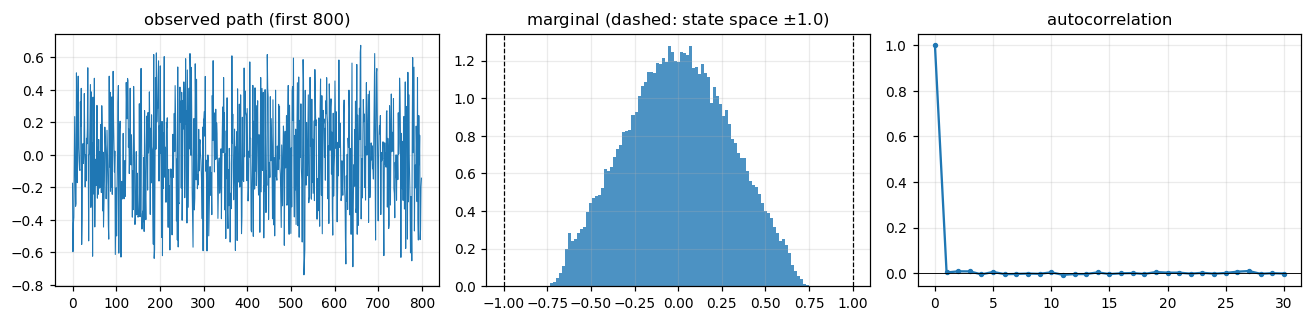

In [389]:
t0 = time.time()
path = simulate_path(target, CFG["T_train"], burn=CFG["burn"], seed=CFG["seed_path"])
print(f"observed path: T = {len(path)}   range [{path.min():.3f}, {path.max():.3f}]   "
      f"std {path.std():.4f}   ({time.time()-t0:.1f}s)")

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(path[:800], lw=0.7); ax[0].set_title("observed path (first 800)")
ax[1].hist(path, bins=90, density=True, color="C0", alpha=.8)
ax[1].axvline(-M, color="k", ls="--", lw=.8); ax[1].axvline(M, color="k", ls="--", lw=.8)
ax[1].set_title(f"marginal (dashed: state space $\\pm${M})")
ax[2].plot(acf(path, 30), marker="o", ms=2.5); ax[2].axhline(0, color="k", lw=.6)
ax[2].set_title("autocorrelation"); plt.tight_layout(); plt.show()

## 4. The supervised dataset

Windows $z_t=(X_{t-1},\dots,X_{t-k})$ paired with the next observed value $X_t$. The path is
needed to *build* these pairs; once built, their order is irrelevant and training shuffles them
freely. No recursion, no sequence model, no innovations.

In [390]:
Z, Xs = make_windows(path, k)
print("windows", Z.shape, " targets", Xs.shape)
print("window occupancy vs the full state space:")
print(f"  observed  z_1 in [{Z[:,0].min():.3f}, {Z[:,0].max():.3f}]")
print(f"  state space          [{-M:.3f}, {M:.3f}]")
print(f"  fraction of X covered: {(Z[:,0].max()-Z[:,0].min())/(2*M):.1%}")

windows (59998, 2)  targets (59998,)
window occupancy vs the full state space:
  observed  z_1 in [-0.803, 0.752]
  state space          [-1.000, 1.000]
  fraction of X covered: 77.7%


## 5. Fit the quantile network

Randomised pinball loss: draw $u\sim U[0,1]$ per example and minimise
$\rho_u\big(X_t-\hat q(u;z_t)\big)$, with $u$ fed as an input. The population minimiser over all
levels is the whole conditional quantile function, which is exactly the object $\hat q(u;z)$ the
theorem needs, and uniformity in $u$ comes for free rather than through a grid of heads.

The Lipschitz penalty targets $\sum_i \mathrm{Lip}_i(\hat q)<1$, measured by autograd. This is
**not optional**: it is what makes the closed recursion have a unique solution, hence makes
$\hat X$ innovation-adapted, hence makes the coupling bicausal. Lose it and the path-law bound
survives while the adapted one does not.

width 256  activation softclip  parameters 1281

  epoch   0   pinball 0.61392   sum_i Lip_i on the state space 0.671
  epoch   5   pinball 0.06567   sum_i Lip_i on the state space 0.548
  epoch  10   pinball 0.06504   sum_i Lip_i on the state space 0.532
  epoch  15   pinball 0.06529   sum_i Lip_i on the state space 0.585
  epoch  20   pinball 0.06481   sum_i Lip_i on the state space 0.571
  epoch  25   pinball 0.06475   sum_i Lip_i on the state space 0.559
  epoch  30   pinball 0.06486   sum_i Lip_i on the state space 0.518
  epoch  35   pinball 0.06490   sum_i Lip_i on the state space 0.594
  epoch  39   pinball 0.06513   sum_i Lip_i on the state space 0.573

trained in 59.4s


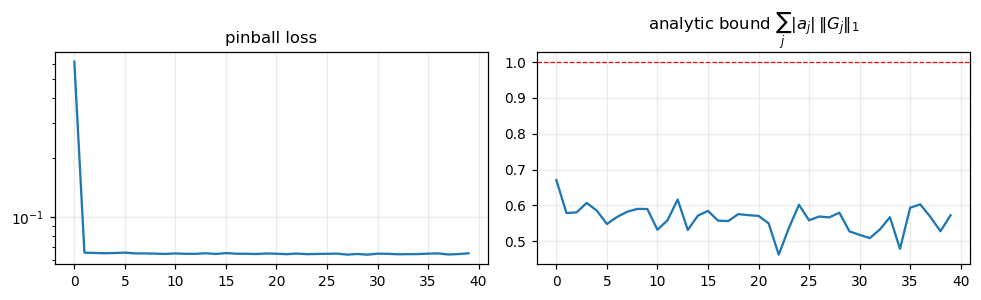

In [391]:
net = QuantileNet(k, width=CFG["width"], act=CFG["act"], seed=CFG["seed_net"])
print(f"width {CFG['width']}  activation {CFG['act']}  parameters "
      f"{sum(p.numel() for p in net.parameters())}\n")
t0 = time.time()
hist = train(net, Z, Xs, epochs=CFG["epochs"], batch=CFG["batch"], lr=CFG["lr"],
             lip_mode=CFG["lip_mode"], L_max=CFG["L_max"], lam=CFG["lam"], M=M,
             seed=CFG["seed_net"], log_every=max(1, CFG["epochs"]//8), tail_frac=CFG["tail_frac"], edge=CFG["edge"])
print(f"\ntrained in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].plot([h["loss"] for h in hist]); ax[0].set_yscale("log"); ax[0].set_title("pinball loss")
ax[1].plot([h["lip_box"] for h in hist]); ax[1].axhline(1.0, color="r", ls="--", lw=.8)
ax[1].set_title(r"analytic bound $\sum_j|a_j|\,\|G_j\|_1$"); plt.tight_layout(); plt.show()

Check if the learned map is monotone (truly a quantile mapping)

In [392]:
def crossing_report(net, Z, n_u=200):
    ug = np.linspace(1e-4, 1 - 1e-4, n_u)
    Q  = np.stack([net.q_np(np.full(len(Z), u), Z) for u in ug])   # (n_u, n_z)
    d  = np.diff(Q, axis=0)
    return {"frac_decreasing": float((d < 0).mean()),
            "worst_fold": float(-np.minimum(d, 0).sum(axis=0).max())}

cross = crossing_report(net, Z, n_u=200)
print("\nCROSSING REPORT")
print(f"  fraction of (u,z) pairs where qhat(u,z) is decreasing: {cross['frac_decreasing']:.4f}")
print(f"  worst fold (max over z of sum_u max(0, -dq/du)): {cross['worst_fold']:.4f}")


CROSSING REPORT
  fraction of (u,z) pairs where qhat(u,z) is decreasing: 0.0000
  worst fold (max over z of sum_u max(0, -dq/du)): -0.0000


## 6. The two hypotheses, measured

The generator proposition needs two things and nothing else: a uniform error $\vartheta$, and
(for the adapted conclusion) uniqueness of the closed recursion, for which
$\sum_i \mathrm{Lip}_i(\hat q)<1$ suffices.

Because the target is known in closed form, $\vartheta$ can be measured directly rather than
inferred. Two regions are reported: the windows the data actually visits, and the full state
space $\mathcal X^k$. The gap between them is the real weakness of this route. The pinball loss
controls an average over the stationary conditioning distribution; the theorem wants a supremum
over a region that includes windows the target never visits, where there is no data and control
has to come from the Lipschitz constraint instead.

UNIQUENESS HYPOTHESIS
data support(qhat)   per-lag [0.2294 0.3049]   sum 0.5342
state space(qhat)   per-lag [0.2464 0.3831]   sum 0.6296   <- the one the theorem needs (need < 1)
analytic bound 15.380   (worst case, vacuous here)

UNIFORM ERROR HYPOTHESIS
  theta on the data support   0.3628   ->  bound theta/(1-S) = 1.2314
  theta on the state space    0.5460   ->  bound theta/(1-S) = 1.8534
    trimmed to u in [0.00, 1.00]:  data 0.3628   state space 0.5460
    trimmed to u in [0.01, 0.99]:  data 0.3004   state space 0.4670
    trimmed to u in [0.05, 0.95]:  data 0.2096   state space 0.3454
    trimmed to u in [0.10, 0.90]:  data 0.1472   state space 0.2530


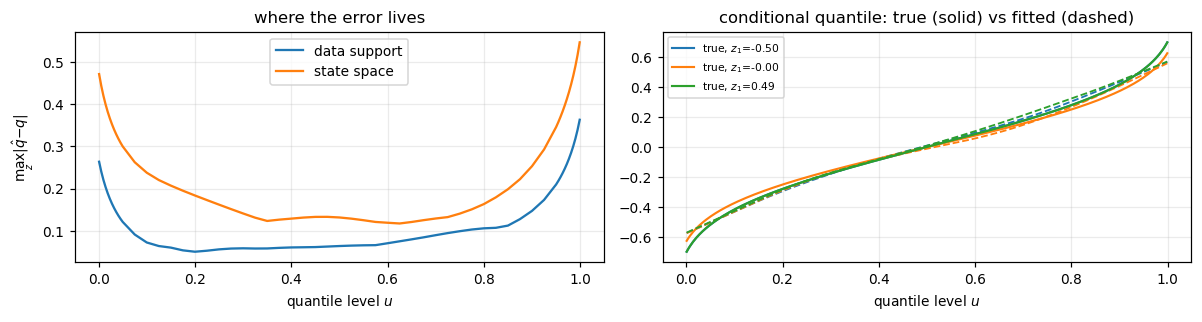

In [393]:
rng    = np.random.default_rng(0)
z_data = Z[rng.integers(0, len(Z), 4000)]
z_box  = rng.uniform(-M, M, size=(4000, k))

pd_, pb_ = lipschitz_empirical(net, z_data), lipschitz_empirical(net, z_box)
print("UNIQUENESS HYPOTHESIS")
print(f"data support(qhat)   per-lag {pd_}   sum {pd_.sum():.4f}")
print(f"state space(qhat)   per-lag {pb_}   sum {pb_.sum():.4f}   <- the one the theorem needs (need < 1)")
print(f"analytic bound {net.lipschitz_bound().item():.3f}   (worst case, vacuous here)")

u_d, e_d = theta_profile(net, target, "data", Z_data=Z, n_z=3000)
u_s, e_s = theta_profile(net, target, "state_space", n_z=3000)
th_d, th_s = float(e_d.max()), float(e_s.max())
print("\nUNIFORM ERROR HYPOTHESIS")
print(f"  theta on the data support   {th_d:.4f}   ->  bound theta/(1-S) = {th_d/(1-S):.4f}")
print(f"  theta on the state space    {th_s:.4f}   ->  bound theta/(1-S) = {th_s/(1-S):.4f}")
for eps in [0.0, 0.01, 0.05, 0.10]:
    print(f"    trimmed to u in [{eps:.2f}, {1-eps:.2f}]:  data {theta_trimmed(u_d,e_d,eps):.4f}"
          f"   state space {theta_trimmed(u_s,e_s,eps):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(u_d, e_d, label="data support"); ax[0].plot(u_s, e_s, label="state space")
ax[0].set_xlabel("quantile level $u$"); ax[0].set_ylabel(r"$\max_z|\hat q-q|$")
ax[0].set_title("where the error lives"); ax[0].legend()
zz = np.quantile(Z[:,0], [0.05, 0.5, 0.95])
ug = np.linspace(0.001, 0.999, 300)
for i, z1 in enumerate(zz):
    zmat = np.tile(np.r_[z1, np.zeros(k-1)], (len(ug), 1))
    ax[1].plot(ug, target.q(ug, zmat), color=f"C{i}", lw=1.4,
               label=f"true, $z_1$={z1:.2f}")
    ax[1].plot(ug, net.q_np(ug, zmat), color=f"C{i}", ls="--", lw=1.2)
ax[1].set_xlabel("quantile level $u$"); ax[1].set_title("conditional quantile: true (solid) vs fitted (dashed)")
ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

The error concentrates at the extreme quantile levels, which is the uniformity-in-$u$ gap: the
pinball loss sees few examples near $u=0$ and $u=1$, and the theorem asks for control there too.
The trimmed values show how much of $\vartheta$ is tail.

## 7. The closed recursion

Fix the weights and iterate $\hat X_t=\hat q(u_t;\hat X_{t-1},\dots,\hat X_{t-k})$ on uniforms
we draw ourselves. No window, no seed and no burn-in are needed by the theory, because the
solution on $\mathbb Z_-$ is unique; the burn-in below is purely numerical.

generated 40000 steps   range [-0.603, 0.615]   std 0.3037
fresh target                 range [-0.782, 0.766]   std 0.2937


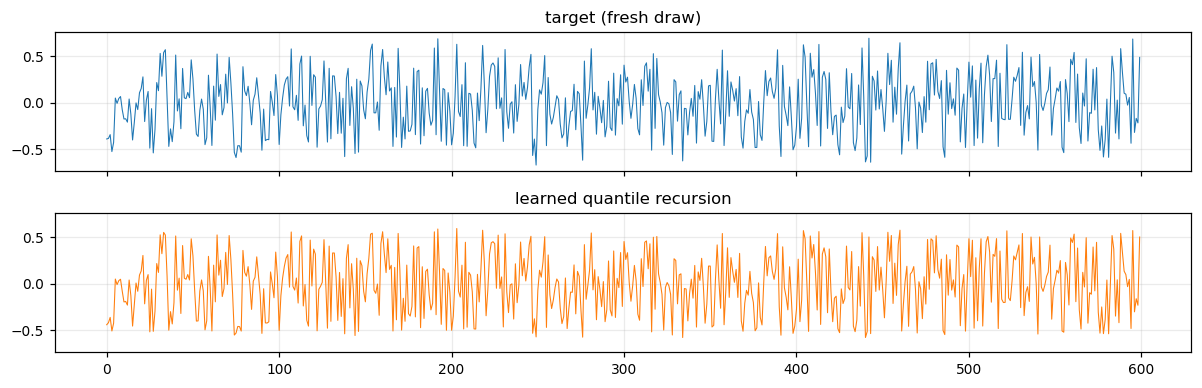

In [394]:
rec = ClosedQuantileRecursion(net)
gen = rec.generate(CFG["T_eval"], burn=CFG["burn"], seed=CFG["seed_eval"])
tru = simulate_path(target, CFG["T_eval"], burn=CFG["burn"], seed=CFG["seed_eval"])
print(f"generated {len(gen)} steps   range [{gen.min():.3f}, {gen.max():.3f}]   std {gen.std():.4f}")
print(f"fresh target                 range [{tru.min():.3f}, {tru.max():.3f}]   std {tru.std():.4f}")

fig, ax = plt.subplots(2, 1, figsize=(11, 3.6), sharex=True, sharey=True)
ax[0].plot(tru[:600], lw=.7, color="C0"); ax[0].set_title("target (fresh draw)")
ax[1].plot(gen[:600], lw=.7, color="C1"); ax[1].set_title("learned quantile recursion")
plt.tight_layout(); plt.show()

## 8. The pathwise bound, checked on the shared-innovation coupling

In practice the target's innovations are invisible. In simulation we control the generator, so we
can form the very coupling the proof uses: drive both recursions with the *same* uniform stream
and measure $\sup_t|X_t-\hat X_t|$ against $\vartheta/(1-S)$.

This is the only place in the notebook where the innovations are used, and it is a verification
step, not part of the procedure.

realised  sup_t |X - Xhat|      0.2534
          mean                  0.0227
          99.9th pct            0.1540
predicted theta/(1-S)  (data)   1.2314      slack x4.9
predicted theta/(1-S)  (state)  1.8534


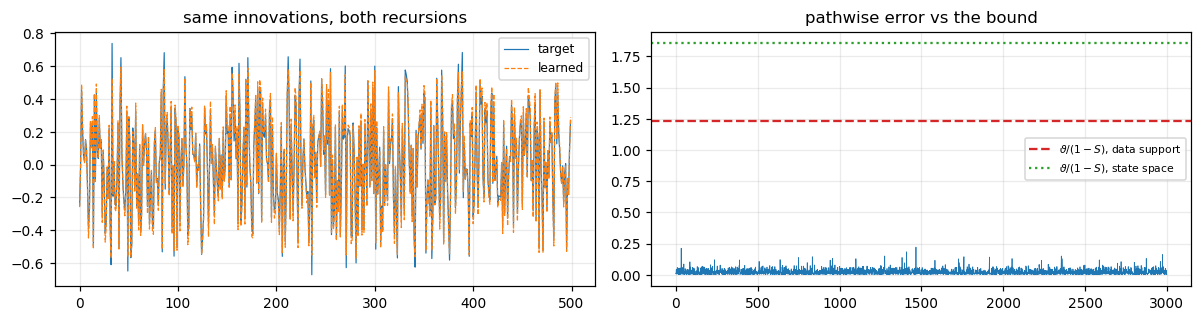

In [395]:
rs = np.random.default_rng(7)
n_pair = 20_000
us = rs.random(n_pair + CFG["burn"])
xt = simulate_path(target, n_pair, burn=CFG["burn"], seed=0, u_stream=us)
xh = rec.generate(n_pair, burn=CFG["burn"], seed=0, u_stream=us)
err = np.abs(xt - xh)

print(f"realised  sup_t |X - Xhat|      {err.max():.4f}")
print(f"          mean                  {err.mean():.4f}")
print(f"          99.9th pct            {np.quantile(err, 0.999):.4f}")
print(f"predicted theta/(1-S)  (data)   {th_d/(1-S):.4f}      slack x{th_d/(1-S)/err.max():.1f}")
print(f"predicted theta/(1-S)  (state)  {th_s/(1-S):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(xt[:500], lw=.8, label="target"); ax[0].plot(xh[:500], lw=.8, ls="--", label="learned")
ax[0].set_title("same innovations, both recursions"); ax[0].legend(fontsize=8)
ax[1].plot(err[:3000], lw=.5)
ax[1].axhline(th_d/(1-S), color="C3", ls="--", label=r"$\vartheta/(1-S)$, data support")
ax[1].axhline(th_s/(1-S), color="C2", ls=":", label=r"$\vartheta/(1-S)$, state space")
ax[1].set_title("pathwise error vs the bound"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 9. Uniqueness, seen directly

Run the learned recursion from many different random initial windows on one shared innovation
stream. If the solution is unique the trajectories must coalesce, and the contraction says they
do so geometrically. This is the echo state property of the closed recursion, and it is what
makes $\hat X$ a function of the innovations alone, hence innovation-adapted, hence bicausally
coupled to the target.

In [396]:
class ExpansiveMap:
    """x_t = clip(lam*x_{t-1} + g(u_t), -M, M),  lam > 1,  sup|g| < (lam-1)M.
    Then +M and -M are both absorbing: lam*M + g(u) >= M always, so a trajectory
    that reaches either endpoint stays there.  For EVERY innovation stream the
    recursion has at least two bounded solutions on Z_-, and the shared-innovation
    coupling is not bicausal."""
    def __init__(self, lam=1.6, M=1.0, c=None):
        self.lam, self.M, self.k = lam, M, 1
        self.c = 0.5*(lam-1)*M if c is None else c
        assert self.c < (lam-1)*M
    def q(self, u, z):
        return float(np.clip(self.lam*z[0] + self.c*(2*float(u)-1), -self.M, self.M))
    def generate(self, n, burn=0, seed=0, u_stream=None, z0=None):
        rng = np.random.default_rng(seed)
        total = burn + n
        u = rng.random(total) if u_stream is None else np.asarray(u_stream, float)[:total]
        z = np.zeros(1) if z0 is None else np.asarray(z0, float).copy()
        out = np.empty(total)
        for s in range(total):
            out[s] = self.q(u[s], z); z[0] = out[s]
        return out[burn:]

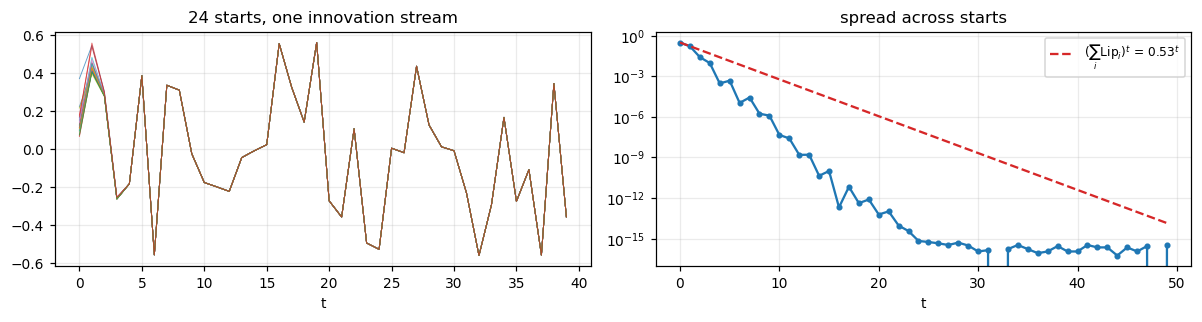

spread at t = 0, 5, 10, 20, 40: [0.3046 0.0005 0.     0.     0.    ]


In [397]:
z0s = np.random.default_rng(3).normal(0, 0.6, size=(24, k))
trajs = np.stack([rec.generate(60, burn=0, seed=0, u_stream=us, z0=z0) for z0 in z0s])
spread = trajs.max(0) - trajs.min(0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
for tr in trajs: ax[0].plot(tr[:40], lw=.6, alpha=.7)
ax[0].set_title("24 starts, one innovation stream"); ax[0].set_xlabel("t")
ax[1].semilogy(spread[:50], marker="o", ms=3)
rate = float(pd_.sum())
ax[1].semilogy(spread[0] * rate ** np.arange(50), ls="--", color="C3",
               label=fr"$(\sum_i \mathrm{{Lip}}_i)^t$ = ${rate:.2f}^t$")
ax[1].set_title("spread across starts"); ax[1].set_xlabel("t"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("spread at t = 0, 5, 10, 20, 40:", spread[[0,5,10,20,40]])

## 10. Comparing the two laws on fresh data

Fresh draws of both processes, with burn-in. Path-law diagnostics first, then the conditional
ones. The whole argument of the paper is that the first group can pass while the second fails.

PATH-LAW DIAGNOSTICS
  W1 between marginals            0.01791   (target std 0.2937)
  ACF lags 1-5   target           [-0.0006  0.007  -0.0056  0.0078 -0.0036]
                 learned          [ 0.0058  0.0128 -0.0039  0.0067 -0.0044]
  block-MMD^2 (L=4)            0.000618   p = 0.192   (null sd 0.000623)

CONDITIONAL DIAGNOSTICS
  aggregate conditional W1        0.02208
  conditional sd range  target    [0.2813, 0.3263]
                        learned   [0.3000, 0.3168]

  ACF of squares, lags 1-5   target    [0.0784 0.041  0.005  0.0035 0.0102]
                             learned   [0.0115 0.0258 0.0008 0.0035 0.0071]


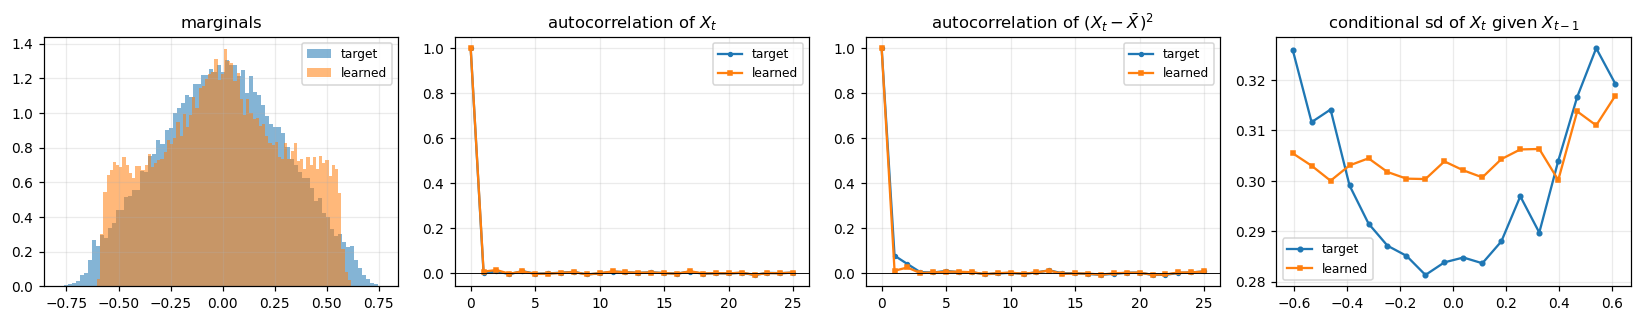

In [398]:
A, Bp = tru, gen                      # fresh target, fresh generated
L_blk = 4
res_gen = mmd_permutation_test(blocks(A, L_blk, 3), blocks(Bp, L_blk, 3), n_perm=150, max_n=900, seed=0)

print("PATH-LAW DIAGNOSTICS")
print(f"  W1 between marginals            {w1_marginal(A, Bp):.5f}   (target std {A.std():.4f})")
print(f"  ACF lags 1-5   target           {acf(A,5)[1:]}")
print(f"                 learned          {acf(Bp,5)[1:]}")
print(f"  block-MMD^2 (L={L_blk})            {res_gen['mmd2']:.6f}   p = {res_gen['p_value']:.3f}"
      f"   (null sd {res_gen['null_std']:.6f})")

bins = np.linspace(np.quantile(A, 0.005), np.quantile(A, 0.995), 19)
w_gen, wt_gen, agg_gen = conditional_w1_profile(A, Bp, bins)
sd_t, _ = conditional_profile(A, bins, "std")
sd_g, _ = conditional_profile(Bp, bins, "std")
print("\nCONDITIONAL DIAGNOSTICS")
print(f"  aggregate conditional W1        {agg_gen:.5f}")
print(f"  conditional sd range  target    [{np.nanmin(sd_t):.4f}, {np.nanmax(sd_t):.4f}]")
print(f"                        learned   [{np.nanmin(sd_g):.4f}, {np.nanmax(sd_g):.4f}]")

sq = lambda x: (x - x.mean()) ** 2

print("\n  ACF of squares, lags 1-5   target    {}".format(acf(sq(A), 5)[1:]))
print("                             learned   {}".format(acf(sq(Bp), 5)[1:]))

mid = 0.5*(bins[:-1]+bins[1:])
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].hist(A,  bins=80, density=True, alpha=.55, label="target")
ax[0].hist(Bp, bins=80, density=True, alpha=.55, label="learned")
ax[0].set_title("marginals"); ax[0].legend(fontsize=8)

ax[1].plot(acf(A, 25),  marker="o", ms=2.5, label="target")
ax[1].plot(acf(Bp, 25), marker="s", ms=2.5, label="learned")
ax[1].axhline(0, color="k", lw=.6)
ax[1].set_title("autocorrelation of $X_t$"); ax[1].legend(fontsize=8)

ax[2].plot(acf(sq(A), 25),  marker="o", ms=2.5, label="target")
ax[2].plot(acf(sq(Bp), 25), marker="s", ms=2.5, label="learned")
ax[2].axhline(0, color="k", lw=.6)
ax[2].set_title(r"autocorrelation of $(X_t-\bar X)^2$"); ax[2].legend(fontsize=8)

ax[3].plot(mid, sd_t, marker="o", ms=3, label="target")
ax[3].plot(mid, sd_g, marker="s", ms=3, label="learned")
ax[3].set_title(r"conditional sd of $X_t$ given $X_{t-1}$"); ax[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

Check MMD

In [399]:
from loss.loss import compute_mmd_loss
import sigkernel_ as ksig_disc
from utils.kernel_helpers import median_heuristic_sigma

def ensemble_target(target, n_paths, L, burn=300, seed=0):
    rng = np.random.default_rng(seed)
    U  = rng.random((n_paths, burn + L))
    Zs = np.zeros((n_paths, target.k)); out = np.empty((n_paths, burn + L))
    for s in range(burn + L):
        out[:, s] = target.q(U[:, s], Zs)
        Zs = np.concatenate([out[:, s:s+1], Zs[:, :-1]], axis=1)
    return torch.as_tensor(out[:, burn:], dtype=torch.float32).unsqueeze(-1)


def ensemble_learned(rec, n_paths, L, burn=300, seed=0):
    rng = np.random.default_rng(seed)
    G, c, ze, a, b, sig = rec.G, rec.c, rec.zeta, rec.a, rec.b, rec._sigma
    U  = rng.random((n_paths, burn + L))
    Zs = np.zeros((n_paths, rec.k)); out = np.empty((n_paths, burn + L))
    for s in range(burn + L):
        H = sig(Zs @ G.T + np.outer(U[:, s], c) + ze)
        out[:, s] = H @ a + b
        Zs = np.concatenate([out[:, s:s+1], Zs[:, :-1]], axis=1)
    return torch.as_tensor(out[:, burn:], dtype=torch.float32).unsqueeze(-1)

Z_target = ensemble_target(target, 100,  200, burn=300, seed=11)   # (100, 200)
Z_gen    = ensemble_learned(rec,   1000, 200, burn=300, seed=12)   # (1000, 200)
print("ensembles", Z_target.shape, Z_gen.shape, " (independent innovations)")

# Train for one epoch to see the effect of a single pass through the data
net_1ep = QuantileNet(k, width=CFG["width"], act=CFG["act"], seed=7)
train(net_1ep, Z, Xs, epochs=1, batch=CFG["batch"], lr=CFG["lr"],
      lip_mode="penalty", L_max=CFG["L_max"], lam=CFG["lam"], M=M, verbose=False)
Z_gen_1ep = ensemble_learned(ClosedQuantileRecursion(net_1ep), 1000, 200, burn=300, seed=13)

# Compute the MMD^2 between the target and generated ensembles
_median_heuristic_sigma = median_heuristic_sigma(Z_target, Z_gen)
_median_heuristic_sigma_1ep = median_heuristic_sigma(Z_target, Z_gen_1ep)
print(f"median heuristic sigma = {_median_heuristic_sigma:.4f}   "
      f"   1-epoch sigma = {_median_heuristic_sigma_1ep:.4f}")

# With median heuristic sigma of Z_target and Z_gen
rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=_median_heuristic_sigma)
val = compute_mmd_loss(rbf_kernel, Z_target.reshape(len(Z_target), -1), Z_gen.reshape(len(Z_gen), -1))
val_1ep = compute_mmd_loss(rbf_kernel, Z_target.reshape(len(Z_target), -1), Z_gen_1ep.reshape(len(Z_gen_1ep), -1))

print("MMD between target and generated ensembles:")
print(f"ensemble MMD^2 = {val:.6f}, 1-epoch MMD^2 = {val_1ep:.6f}")


ensembles torch.Size([100, 200, 1]) torch.Size([1000, 200, 1])  (independent innovations)
median heuristic sigma = 6.0777      1-epoch sigma = 5.4323
MMD between target and generated ensembles:
ensemble MMD^2 = 0.000539, 1-epoch MMD^2 = 0.006467


## 11. Why the path-law diagnostics are not enough

A matched Gaussian AR($k$), fitted by least squares to the same observed path. It reproduces the
mean, the variance and the autocorrelation essentially exactly, and by construction has a
*constant* conditional spread. So it passes every second-order check and gets the conditional
structure wrong.

The comparison to look at is the conditional standard deviation profile, and the table below it.
Read the table honestly: the matched AR wins on the autocorrelation, because that is precisely
what it was fitted to, and it is the model with the wrong conditional structure. The separation
appears only in the conditional columns.

fitted AR(2):  phi = [0.0032 0.0083]   sigma = 0.2962

                           learned   matched AR     (target cond. sd range 0.0450)
W1 marginal                0.01791      0.01343
|ACF(1) gap|               0.00644      0.00528
|ACF(2) gap|               0.00581      0.00232
block-MMD^2                0.00062      0.00055
MMD p-value                0.19205      0.15232
conditional W1             0.02208      0.01759
cond. sd range             0.01681      0.01833

K = 0.1,  5 exercise dates
                    target   learned        AR   rel. error learned / AR
European           0.17693   0.18198   0.17404   +2.86% / -1.63%
Bermudan           0.38914   0.40356   0.38631   +3.70% / -0.73%
early-ex. prem.    0.21222   0.22157   0.21227


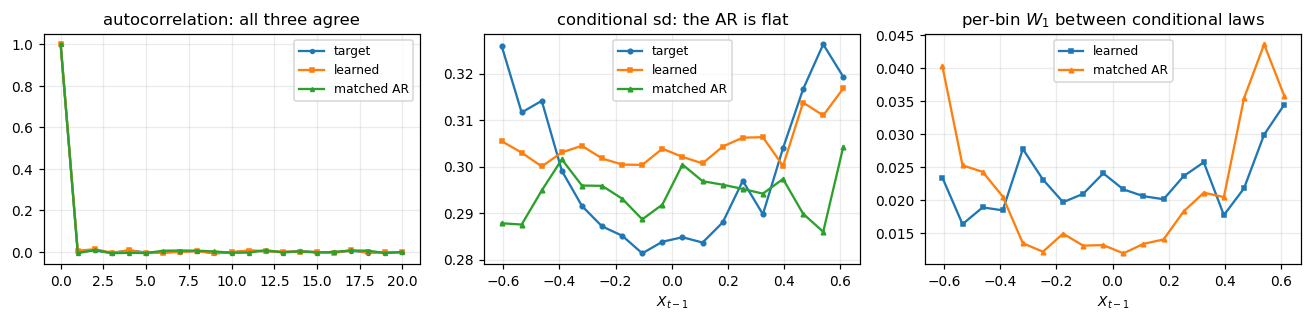

In [400]:
ar = MatchedGaussianAR(p=k).fit(path)
Cp = ar.simulate(CFG["T_eval"], burn=CFG["burn"], seed=CFG["seed_eval"])
print(f"fitted AR({k}):  phi = {ar.phi.round(4)}   sigma = {ar.sigma:.4f}\n")

res_ar = mmd_permutation_test(blocks(A, L_blk, 3), blocks(Cp, L_blk, 3), n_perm=150, max_n=900, seed=0)
w_ar, wt_ar, agg_ar = conditional_w1_profile(A, Cp, bins)
sd_a, _ = conditional_profile(Cp, bins, "std")

rows = [("W1 marginal",        w1_marginal(A, Bp),  w1_marginal(A, Cp)),
        ("|ACF(1) gap|",       abs(acf(A,1)[1]-acf(Bp,1)[1]), abs(acf(A,1)[1]-acf(Cp,1)[1])),
        ("|ACF(2) gap|",       abs(acf(A,2)[2]-acf(Bp,2)[2]), abs(acf(A,2)[2]-acf(Cp,2)[2])),
        ("block-MMD^2",        res_gen["mmd2"],     res_ar["mmd2"]),
        ("MMD p-value",        res_gen["p_value"],  res_ar["p_value"]),
        ("conditional W1",     agg_gen,             agg_ar),
        ("cond. sd range",     np.nanmax(sd_g)-np.nanmin(sd_g), np.nanmax(sd_a)-np.nanmin(sd_a))]
print(f"{'':22s}{'learned':>12s}{'matched AR':>13s}     (target cond. sd range "
      f"{np.nanmax(sd_t)-np.nanmin(sd_t):.4f})")
for nm, a_, b_ in rows:
    print(f"{nm:22s}{a_:12.5f}{b_:13.5f}")

K, NE = CFG["strike"], CFG["n_exercise"]
eu = [european_put_h(p_, K, NE) for p_ in (A, Bp, Cp)]
be = [bermudan_put(p_, K, NE)   for p_ in (A, Bp, Cp)]
print(f"\nK = {K},  {NE} exercise dates")
print(f"{'':16s}{'target':>10s}{'learned':>10s}{'AR':>10s}   rel. error learned / AR")
print(f"{'European':16s}{eu[0]:10.5f}{eu[1]:10.5f}{eu[2]:10.5f}   "
      f"{100*(eu[1]-eu[0])/eu[0]:+.2f}% / {100*(eu[2]-eu[0])/eu[0]:+.2f}%")
print(f"{'Bermudan':16s}{be[0]:10.5f}{be[1]:10.5f}{be[2]:10.5f}   "
      f"{100*(be[1]-be[0])/be[0]:+.2f}% / {100*(be[2]-be[0])/be[0]:+.2f}%")
print(f"{'early-ex. prem.':16s}{be[0]-eu[0]:10.5f}{be[1]-eu[1]:10.5f}{be[2]-eu[2]:10.5f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(acf(A,20), marker="o", ms=2.5, label="target")
ax[0].plot(acf(Bp,20), marker="s", ms=2.5, label="learned")
ax[0].plot(acf(Cp,20), marker="^", ms=2.5, label="matched AR")
ax[0].set_title("autocorrelation: all three agree"); ax[0].legend(fontsize=8)
ax[1].plot(mid, sd_t, marker="o", ms=3, label="target")
ax[1].plot(mid, sd_g, marker="s", ms=3, label="learned")
ax[1].plot(mid, sd_a, marker="^", ms=3, label="matched AR")
ax[1].set_title("conditional sd: the AR is flat"); ax[1].set_xlabel(r"$X_{t-1}$"); ax[1].legend(fontsize=8)
ax[2].plot(mid, w_gen, marker="s", ms=3, label="learned")
ax[2].plot(mid, w_ar,  marker="^", ms=3, label="matched AR")
ax[2].set_title(r"per-bin $W_1$ between conditional laws"); ax[2].set_xlabel(r"$X_{t-1}$")
ax[2].legend(fontsize=8); plt.tight_layout(); plt.show()

Two findings, one positive and one negative, and the negative one matters.

**Positive.** The conditional diagnostics separate the two models cleanly and the path-law ones
do not. The learned recursion recovers most of the target's conditional-sd variation while the
matched AR recovers almost none of it, and the aggregate conditional $W_1$ is correspondingly
smaller. Meanwhile the matched AR matches the autocorrelation *better* than the learned model
does, which is the sharper form of the paper's point: the model that wins on the standard
second-order diagnostic is the structurally wrong one.

**Negative.** At this effect size the Bermudan price does *not* separate them. Both models
underprice it by a similar margin. So optimal stopping is a coarser probe of the conditional
structure than the conditional-$W_1$ profile is, at least here. Do not claim otherwise on the
strength of this example.

The effect is bounded for a structural reason worth noticing: the standing assumption $S<1$ caps
how state-dependent the conditional scale can be, because that dependence is charged to
$\ell_1$. Admissible targets cannot be wildly heteroskedastic. Raise `kappa` or `s1` in `CFG`
and the assumption fails before the pricing gap becomes large.

## 12. The echo state network realisation

None of the above used a reservoir. The realisation proposition says the trained map can be
written *inside* a plain echo state network,

$$h_t=\sigma(Ah_{t-1}+cu_t+\zeta),\qquad \hat X_t=w^\top h_t,\qquad A=GE,\quad w^\top=e_1^\top E,$$

with the last $k-1$ coordinates of $Eh_t$ realising the shift **exactly**, so that
$Eh_t=(\hat X_t,\dots,\hat X_{t-k+1})$ and the network is $k$-Markov in its own output. That
exactness is what makes the coupling bicausal, and it is why the activation must be affine on an
interval, which $\tanh$ is not and `softclip` is.

The check below is that the wrapped network reproduces the recursion to machine precision, and
that $A$ is $N\times N$ with rank at most $k$.

In [401]:
if CFG["act"] != "softclip":
    print("set CFG['act'] = 'softclip' and re-run: the exact shift needs sigma affine on an interval")
else:
    esn = ESNWrap(net, operating_radius=1.6 * M)
    info = esn.info()
    print(f"reservoir dimension N = {info['N']}  =  width {CFG['width']} + shift {k-1} + constant 1")
    print(f"A is {info['A_shape']} with rank {info['rank_A']}   (<= k = {k})")
    print(f"readout w = e_1^T E, so the readout sits inside A = GE: they cannot be trained separately\n")
    xe = esn.generate(2000, burn=500, seed=0, u_stream=us)
    xr = rec.generate(2000, burn=500, seed=0, u_stream=us)
    print(f"max |ESN - direct recursion| over 2000 steps: {np.abs(xe-xr).max():.3e}")

reservoir dimension N = 258  =  width 256 + shift 1 + constant 1
A is (258, 258) with rank 2   (<= k = 2)
readout w = e_1^T E, so the readout sits inside A = GE: they cannot be trained separately

max |ESN - direct recursion| over 2000 steps: 6.661e-16


## 13. Summary

In [402]:
print(f"target                         {target.name}")
print(f"S = sum_i ell_i                {S:.4f}        amplification 1/(1-S) = {1/(1-S):.3f}")
print(f"sum_i Lip_i(qhat)              {pb_.sum():.4f}        (uniqueness needs < 1)")
print(f"theta, data support            {th_d:.4f}        bound {th_d/(1-S):.4f}")
print(f"theta, full state space        {th_s:.4f}        bound {th_s/(1-S):.4f}")
print(f"realised sup_t |X - Xhat|      {err.max():.4f}")
print(f"conditional W1, learned        {agg_gen:.5f}")
print(f"conditional W1, matched AR     {agg_ar:.5f}")
print(f"Bermudan rel. error, learned   {100*(be[1]-be[0])/be[0]:+.2f}%")
print(f"Bermudan rel. error, AR        {100*(be[2]-be[0])/be[0]:+.2f}%")

target                         ARCH(k=2, S=0.705)
S = sum_i ell_i                0.7054        amplification 1/(1-S) = 3.395
sum_i Lip_i(qhat)              0.6296        (uniqueness needs < 1)
theta, data support            0.3628        bound 1.2314
theta, full state space        0.5460        bound 1.8534
realised sup_t |X - Xhat|      0.2534
conditional W1, learned        0.02208
conditional W1, matched AR     0.01759
Bermudan rel. error, learned   +3.70%
Bermudan rel. error, AR        -0.73%


### What this does and does not show

It shows that the one-step quantile can be fitted from an observed path with no access to the
innovations, that the closed recursion has a unique solution and forgets its initial window
geometrically, that the pathwise bound holds with room, and that the exact-shift realisation is
exact.

It does not show that training reaches a certified $\vartheta$. Two gaps are visible in the
output above and both are real. The error at the extreme quantile levels is large, because the
pinball loss sees few examples there and the theorem asks for uniformity in $u$. And $\vartheta$
on the full state space is much larger than on the data support, because the loss controls an
average over the stationary conditioning distribution while the theorem wants a supremum over a
region where there is no data. Off the data support the only control available is the Lipschitz
constraint on the architecture.

# Appendix

## Appendix A. The contraction condition is sufficient, not necessary

Section 9 showed the spread across 24 starts collapsing geometrically, which is the
numerical certificate of uniqueness: for a fixed innovation stream every trajectory
converges to the same solution, so $\hat X$ is a function of the innovations alone,
which is what Proposition 6.6 consumes.

The hypothesis that guarantees this is $\sum_i \mathrm{Lip}_i(\hat q) < 1$. Two
experiments locate how much slack there is in it.

**A.1** rescales the state weights, $G \mapsto \rho G$, and measures the resulting
Lipschitz sum on the state space together with the terminal spread. Note that the
sum must be *measured*, not assumed to be $\rho$ times the original: large $\rho$
pushes units into softclip's saturation where $\sigma' \to 0$, so the map's
sensitivity is not linear in $\rho$.

**A.2** constructs a recursion that provably has two solutions for every innovation
stream, to show what the condition is protecting against.

## A.1

  rho  sum_i Lip_i (state space)  spread t=0       t=20       t=79
  1.0                      0.631      0.3046    0.00000    0.00000
  1.5                      1.388      0.6490    0.00000    0.00000
  2.0                      2.031      0.9547    0.00000    0.00000
  3.0                      3.778      1.3420    0.00000    0.00000
  5.0                      6.504      1.9471    0.05819    0.00000
  6.5                      8.519      2.1469    0.94893    0.54648
  8.0                     10.585      2.2097    1.52208    0.73636
 15.0                     18.683      2.1509    1.83703    2.22485


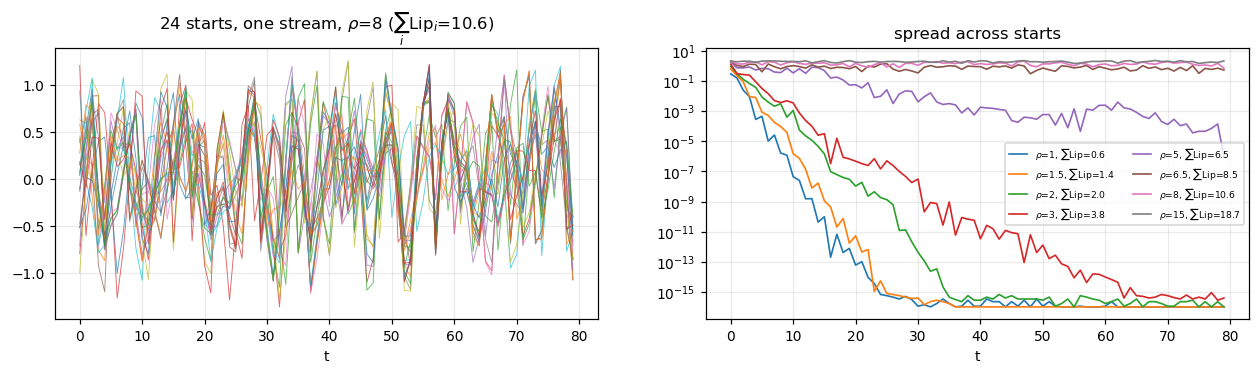

In [403]:
# --- A.1  rescale the state weights and watch uniqueness fail --------------
RHOS = [1.0, 1.5, 2.0, 3.0, 5.0, 6.5, 8.0, 15.0]
T_A, rng_A = 80, np.random.default_rng(0)
base_G = net.G.detach().clone()
res = []
try:
    for rho in RHOS:
        with torch.no_grad():
            net.G.copy_(base_G * rho)
        L  = float(lipschitz_empirical(net, rng_A.uniform(-M, M, (2500, k))).sum())
        r_ = ClosedQuantileRecursion(net)
        tr = np.stack([r_.generate(T_A, burn=0, seed=0, u_stream=us, z0=z) for z in z0s])
        res.append({"rho": rho, "L": L, "spread": tr.max(0) - tr.min(0), "traj": tr})
finally:
    with torch.no_grad():
        net.G.copy_(base_G)                      # always restore the trained net

print(f"{'rho':>5} {'sum_i Lip_i (state space)':>26} {'spread t=0':>11} {'t=20':>10} {'t=79':>10}")
for r in res:
    s = r["spread"]
    print(f"{r['rho']:5.1f} {r['L']:26.3f} {s[0]:11.4f} {s[20]:10.5f} {s[-1]:10.5f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 3.2))

# which rho to plot?  pick the one that is exactly 5.0
plot_rho = 8.0
index = next(i for i, r in enumerate(res) if r["rho"] == plot_rho)
for tr in res[index]["traj"]:
    ax[0].plot(tr, lw=.6, alpha=.7)
ax[0].set_title(fr"24 starts, one stream, $\rho$={res[index]['rho']:.0f} "
                fr"($\sum_i\mathrm{{Lip}}_i$={res[index]['L']:.1f})")
ax[0].set_xlabel("t")

for r in res:
    ax[1].semilogy(np.maximum(r["spread"], 1e-16), lw=1.1,
                   label=fr"$\rho$={r['rho']:g}, $\sum\mathrm{{Lip}}$={r['L']:.1f}")
ax[1].set_title("spread across starts"); ax[1].set_xlabel("t")
ax[1].legend(fontsize=6, ncol=2)

## A.2

expansive map, lam = 1.6:  sum_i Lip_i = 1.6 > 1
  spread at t = 0, 5, 20, 79: [2. 2. 2. 2.]
  terminal values: {-1.0: 11, 1.0: 13}


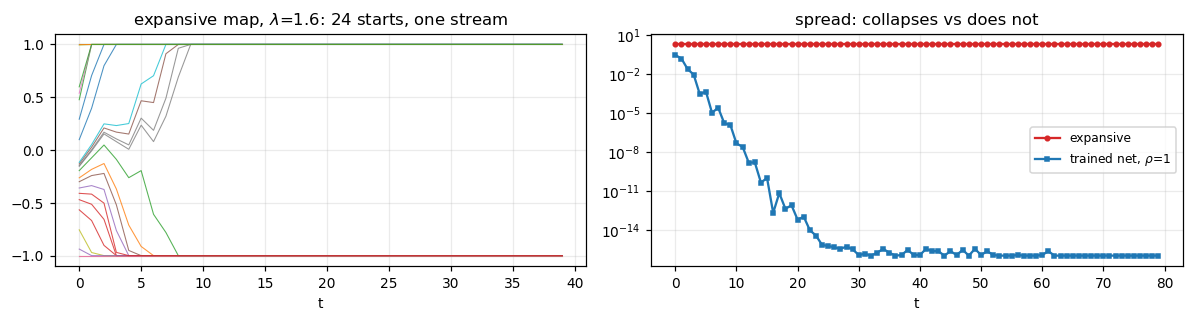

In [404]:
# --- A.2  a recursion with provably two solutions --------------------------
class ExpansiveMap:
    """x_t = clip(lam*x_{t-1} + g(u_t), -M, M),  lam > 1,  sup|g| < (lam-1)M.

    Then lam*M + g(u) >= M for every u, so +M is absorbing, and likewise -M.
    For EVERY innovation stream the recursion therefore has at least two bounded
    solutions on Z_-.  The shared-innovation coupling is not bicausal, because
    the output is not a measurable function of the innovations at all.
    """
    def __init__(self, lam=1.6, M=1.0, c=None):
        self.lam, self.M, self.k = lam, M, 1
        self.c = 0.5 * (lam - 1) * M if c is None else c
        assert self.c < (lam - 1) * M, "noise too large: the endpoints stop being absorbing"

    def q(self, u, z):
        return float(np.clip(self.lam * z[0] + self.c * (2 * float(u) - 1), -self.M, self.M))

    def generate(self, n, burn=0, seed=0, u_stream=None, z0=None):
        rng = np.random.default_rng(seed)
        total = burn + n
        u = rng.random(total) if u_stream is None else np.asarray(u_stream, float)[:total]
        z = np.zeros(1) if z0 is None else np.asarray(z0, float).copy()
        out = np.empty(total)
        for s in range(total):
            out[s] = self.q(u[s], z); z[0] = out[s]
        return out[burn:]


em   = ExpansiveMap(lam=1.6, M=M)
z0_1 = np.random.default_rng(3).normal(0, 0.6, size=(24, 1))
tr_e = np.stack([em.generate(T_A, seed=0, u_stream=us, z0=z) for z in z0_1])
sp_e = tr_e.max(0) - tr_e.min(0)

print(f"expansive map, lam = {em.lam}:  sum_i Lip_i = {em.lam} > 1")
print("  spread at t = 0, 5, 20, 79:", sp_e[[0, 5, 20, T_A - 1]].round(4))
vals, cnt = np.unique(np.round(tr_e[:, -1], 6), return_counts=True)
print("  terminal values:", dict(zip(vals, cnt)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
for tr in tr_e:
    ax[0].plot(tr[:40], lw=.7, alpha=.8)
ax[0].set_title(fr"expansive map, $\lambda$={em.lam}: 24 starts, one stream")
ax[0].set_xlabel("t")
ax[1].semilogy(np.maximum(sp_e, 1e-16), marker="o", ms=3, color="C3", label="expansive")
ax[1].semilogy(np.maximum(res[0]["spread"], 1e-16), marker="s", ms=3, color="C0",
               label=fr"trained net, $\rho$=1")
ax[1].set_title("spread: collapses vs does not"); ax[1].set_xlabel("t")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### What the two experiments say

**A.2 first, because it is the clean statement.** With $\lambda > 1$ and the noise
small enough that both endpoints are absorbing, the spread sits at the full diameter
$2M$ forever and the 24 starts split permanently into two groups. Same innovations,
two different bounded solutions. So $\hat X$ is not a measurable function of $u$,
there is nothing for it to be adapted to, and Proposition 6.6 has no hypothesis to
consume. That is the failure mode the contraction rules out.

**A.1 shows the condition is far from tight.** Read the third panel: the vertical
line marks the hypothesis $\sum_i \mathrm{Lip}_i = 1$, and the terminal spread stays
at machine zero well past it. In one run the measured sum was already $1.24$ at
$\rho = 1$ with uniqueness intact, and the spread only stopped collapsing somewhere
between $\sum_i\mathrm{Lip}_i \approx 5$ and $\approx 8$.

The reason is structural, not numerical. $\sum_i \mathrm{Lip}_i < 1$ is a *global,
worst-case* condition: it asks the map to be a contraction at every point of the
state space simultaneously, in the crudest norm. Uniqueness only needs the dynamics
to forget along the trajectories the process actually visits. A map can be locally
expansive in regions it rarely enters, or expansive in one coordinate while
contracting in the weighted norm of Lemma 2.9, and still have a unique solution.

Two consequences worth stating in the paper. The hypothesis is what can be
*verified* from the fitted model, not what the system needs, so the gap between the
two is slack the theorem gives away and not a defect of the theorem. And the
practical guidance is the opposite of what the slack suggests: since nothing
certifies uniqueness when the condition fails, and since losing uniqueness costs the
entire adapted conclusion while leaving the path-law one intact, the constraint
should be enforced during training rather than checked afterwards and hoped for.

# Tail fitting problem

In [405]:
def report(net, target, Z, nbin=8,
           pairs=((0.25,0.75),(0.05,0.95),(0.01,0.99),(0.001,0.999))):
    n = len(Z)
    ref = target.q(np.full(n, 0.999), Z) - target.q(np.full(n, 0.001), Z)
    qs  = np.quantile(ref, np.linspace(0, 1, nbin + 1))
    idx = np.clip(np.digitize(ref, qs) - 1, 0, nbin - 1)
    out = {}
    for lo, hi in pairs:
        l, h = np.full(n, lo), np.full(n, hi)
        rn = net.q_np(h, Z) - net.q_np(l, Z)
        rt = target.q(h, Z) - target.q(l, Z)
        out[(lo, hi)] = np.array([rn[idx == b].mean() / rt[idx == b].mean()
                                  for b in range(nbin)])
    A = out[(0.25,0.75)][0] / out[(0.25,0.75)][-1]      # scale tracking, target 1.0
    B = out[(0.001,0.999)][0] / out[(0.25,0.75)][0]     # level shape,    target 1.0
    return out, A, B


print("\nREPORT: scale tracking and level shape")
rep, A, B = report(net, target, Z, nbin=8)
print(f"  scale tracking (target 1.0) = {A:.4f}")
print(f"  level shape    (target 1.0) = {B:.4f}")


REPORT: scale tracking and level shape
  scale tracking (target 1.0) = 1.0452
  level shape    (target 1.0) = 0.8363
